# Paper Metrics — Validation & Visualization

Literature-style face-validity figures for the paper metrics, all rendered inline:
1. **Disruption frequency spectrum** (raw CD distribution, symlog).
2. **Team size → disruption percentile & impact** (Wu et al. 2019 Fig 2a style: small teams disrupt, large teams get cited).
3. **Atypicality 2×2 hit probability** (Uzzi et al. 2013: median conventionality × tail novelty → hit-paper rate).
4. **Atypicality CDF** (distribution of median & 10th-pct Z).
5. **Sleeping Beauty** validation (B / T distributions, B vs eventual citations, top sleeping beauties).

Inputs: `/project/jevans/Dawoon/Science of Science/OpenAlex/output/{paper_disruption, paper_citation, paper_metadata, paper_sb, paper_hit_probability, paper_z_score}.parquet`.
Atypicality figures need `paper_z_score.parquet` (decade 1990–2000); they are skipped gracefully if it is absent.

In [1]:
import os, sys, duckdb
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import host_subplot
import matplotlib.ticker as ticker
%matplotlib inline
plt.rcParams['figure.dpi'] = 110

sys.path.insert(0, '/project/jevans/Dawoon/Science of Science/validation')
import val_common as V
V.init('paper_validation')
P = V.paper                    # notebook/paper/output -> Science of Science/OpenAlex/output
ROOT = V.BASE
DISR, CIT, META = P('paper_disruption.parquet'), P('paper_citation.parquet'), P('paper_metadata.parquet')
SB, HIT = P('paper_sb.parquet'), P('paper_hit_probability.parquet')
AU = P('paper_author.parquet')          # our own team size, replaces SciSciNet's in section 2

# THE MERGED FILE, WITH ITS COVERAGE READ FROM DISK RATHER THAN ASSUMED.
# paper_z_score.parquet is written by paper_z_score_merge.ipynb from the 14 post-fix partitions
# (41,425,041 papers, no year gap, no duplicate paper_id). The merge excludes `_old` and
# `_2000_2005`: both predate the MAG-alignment fix, which changed the journal mapping from "any
# work with a primary-location source" (275.2M, 63% of them not journals) to "is_journal only"
# (108.1M) and moved Z_median's mean from 10.5 to 167.0. The two vintages are different
# quantities and must not be pooled.
#
# A bare name conventionally means FULL_RANGE (1900-2020); this file is EXTENDED_RANGE
# (1980-2020). The provenance sidecar records that, and it is READ here rather than hard-coded,
# so a later re-merge over a different span cannot silently mislabel these figures.
import json as _json
ZS = P('paper_z_score.parquet')
ZP = P('z_score_pair.parquet')
HAS_Z = os.path.exists(ZS)
_prov = f"{V.OA_OUT}/paper_z_score_provenance.json"
if HAS_Z and os.path.exists(_prov):
    _p = _json.load(open(_prov))
    Z_COVER = f"{_p['coverage_years'][0]}-{_p['coverage_years'][1]}"
    Z_VINTAGE = _p['vintage']
    Z_PARTS = len(_p.get('partitions', []))
else:
    Z_COVER, Z_VINTAGE, Z_PARTS = 'unknown', 'unknown', 0
print(f'z-score : {os.path.basename(ZS)}   coverage {Z_COVER}   ({Z_PARTS} partitions merged)')
print(f'          vintage: {Z_VINTAGE}')
con = duckdb.connect(); con.execute("SET memory_limit='16GB'")
con.execute(f"SET temp_directory='{V.TMP}'")
V.preflight()

[val] paper_validation  ->  /project/jevans/Dawoon/Science of Science/validation/Figures/paper_validation_<section>.{jpg,pdf}  @ 600 dpi
z-score : paper_z_score.parquet   coverage 1980-2020   (14 partitions merged)
          vintage: post-MAG-alignment fix (is_journal-only mapping) and post two-pass rewrite
  paper_validation    OK


True

## 1. Disruption frequency spectrum (raw CD, symlog)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

88,451,628 papers with CD_all
  [fig] paper_validation_1.jpg + .pdf  (600 dpi)


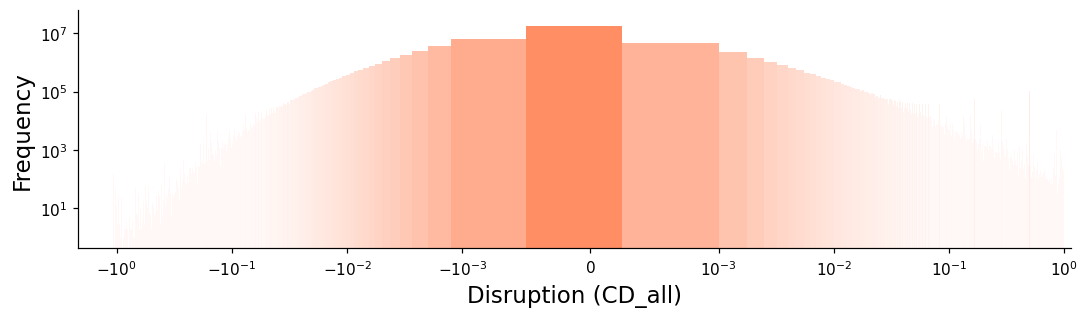

CD_all: mean +0.3005  median +0.0004  frac>0 55.5%
CPU times: user 14.4 s, sys: 891 ms, total: 15.3 s
Wall time: 17.4 s


In [2]:
%%time
D1 = con.execute(f"SELECT CD_all FROM read_parquet('{DISR}') WHERE CD_all IS NOT NULL").fetchnumpy()['CD_all'].astype(float)
print(f'{len(D1):,} papers with CD_all')
nbins = 4000
fig = plt.figure(figsize=(10, 3), facecolor='white'); ax = fig.add_subplot(111)
N, bins, patches = ax.hist(D1, bins=nbins, edgecolor='white', linewidth=0)
LN = np.log(max(N))
delta = bins[1] - bins[0]
peaks = set([j / i for i in range(1, 60) for j in range(1, i)] + [-j / i for i in range(1, 60) for j in range(1, i)])
for i in range(len(patches)):
    h = patches[i].get_height()
    if h > 0:
        r = (np.log(h) / LN) ** 5
        patches[i].set_alpha(min(max(r, 0.05), 1.0)); patches[i].set_facecolor('Coral')
plt.yscale('log'); plt.xscale('symlog', linthresh=0.001); plt.tight_layout()
plt.xlabel('Disruption (CD_all)', fontsize=15); plt.ylabel('Frequency', fontsize=15)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
V.save('1')
print(f'CD_all: mean {D1.mean():+.4f}  median {np.median(D1):+.4f}  frac>0 {(D1>0).mean()*100:.1f}%')

## 2. Team size → disruption percentile & impact (Wu et al. Fig 2a style)

Team size is **ours**, from `output/paper_author.parquet` — the count of distinct `author_id`s
per work, built by `notebook/paper_author.ipynb` from the snapshot's
`works_au_affs_fixed.csv.gz`. It replaces SciSciNet's `team_size`, which this section used to
borrow because `paper_metadata.author_list` is 100% null (`RUN_AUTHORS=False`).

The borrowed column is not missed: over all **251,654,553** works the two agree on team size
**exactly, row for row**, with neither file covering a work the other lacks. What our file adds
is a producer — `paper_team_size.parquet` had none anywhere in the project and could not be
regenerated — plus `author_list`, `first_author` and `last_author`, which it never carried.

The count is of **distinct authors**, not of rows: the source file has one row per
(work, author, *affiliation*), so 17.8% of rows are duplicate (work, author) pairs and counting
rows inflates mean team size from 2.93 to 3.62.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

 team_size       dis   dis_ci       cit   cit_ci       n
         1 56.593436 0.020239 12.801095 0.040781 7823472
         2 50.078686 0.019704 18.621360 0.048256 8192153
         3 48.797596 0.021884 20.473013 0.048139 6577492
         4 47.847046 0.026222 22.576218 0.058556 4566913
         5 46.447994 0.032155 25.278543 0.306080 2972150
         6 45.064735 0.038974 27.869102 0.095364 1967986
         7 43.656102 0.048896 31.376975 0.126943 1194885
         8 42.650615 0.060332 34.937416 0.198961  762307
         9 41.748542 0.075538 38.574450 0.266739  474872
        10 41.052984 0.090653 42.506210 0.359476  325740
  [fig] paper_validation_2.jpg + .pdf  (600 dpi)


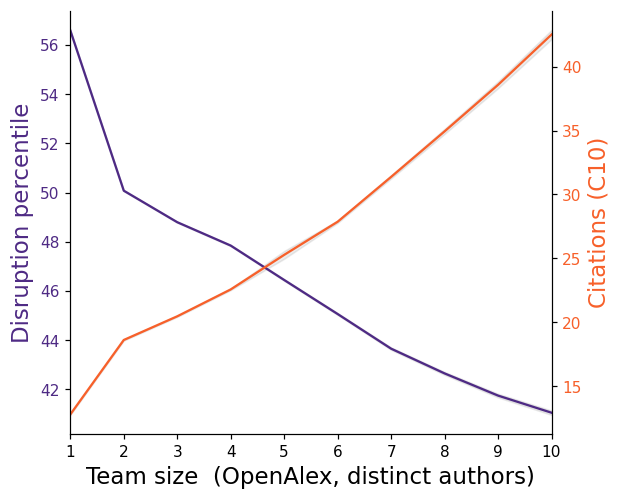

CPU times: user 1min 50s, sys: 9.26 s, total: 1min 59s
Wall time: 46.3 s


In [3]:
%%time
# Disruption percentile over the analysis set, then mean by team size with a 95% CI.
# TEAM SIZE IS OURS -- paper_author.parquet, distinct author_id per work. This section
# borrowed SciSciNet's column until paper_author.ipynb existed; the two were then found to
# agree on all 251,654,553 works, so the switch changes the provenance, not the figure.
q = f'''
WITH base AS (
  SELECT d.CD_all, c.C_10, a.team_size
  FROM read_parquet('{DISR}') d
  JOIN read_parquet('{CIT}') c USING (paper_id)
  JOIN read_parquet('{META}') m USING (paper_id)
  JOIN read_parquet('{AU}') a ON a.work_id = d.paper_id
  WHERE d.CD_all IS NOT NULL AND a.team_size BETWEEN 1 AND 10
    AND m.ref_count >= 1 AND m.year BETWEEN 1954 AND 2014
),
ranked AS (SELECT team_size, C_10, percent_rank() OVER (ORDER BY CD_all) AS dpct FROM base)
SELECT team_size,
       avg(dpct)*100 AS dis, 1.96*stddev(dpct)/sqrt(count(*))*100 AS dis_ci,
       avg(C_10)     AS cit, 1.96*stddev(C_10)/sqrt(count(*))     AS cit_ci, count(*) AS n
FROM ranked GROUP BY team_size ORDER BY team_size
'''
try:
    g = con.execute(q).fetchdf()
    print(g.to_string(index=False))
except Exception as e:
    g = None
    print(f'[skip 2] {str(e)[:220]}')

if g is not None and len(g):
    x = g['team_size'].values; col1, col2 = '#4E2A84', '#F7602A'
    fig = plt.figure(figsize=(5, 5), facecolor='white'); host = host_subplot(111)
    plt.subplots_adjust(right=1)
    par1 = host.twinx()
    host.plot(x, g['dis'], color=col1, label='Disruption')
    par1.plot(x, g['cit'], color=col2, label='Impact')
    host.fill_between(x, g['dis'] - g['dis_ci'], g['dis'] + g['dis_ci'], color='gray', alpha=0.15)
    par1.fill_between(x, g['cit'] - g['cit_ci'], g['cit'] + g['cit_ci'], color='gray', alpha=0.15)
    host.set_xlim(1, 10); host.set_xlabel('Team size  (OpenAlex, distinct authors)', size=15)
    host.set_ylabel('Disruption percentile', size=15); par1.set_ylabel('Citations (C10)', size=15)
    host.yaxis.label.set_color(col1); par1.yaxis.label.set_color(col2)
    host.tick_params(axis='y', labelcolor=col1); par1.tick_params(axis='y', labelcolor=col2)
    host.spines['top'].set_visible(False); par1.spines['top'].set_visible(False)
    V.save('2', tight=False)


## 3. Atypicality 2×2 — hit-paper probability (Uzzi et al.)

Median conventionality is `Z_median`; tail novelty is a **low** `Z_10pct`. Each axis is split
into high/low at the median of the paper's **own publication-year cohort**, not at the pooled
median over all years. `Z_median` drifts with year (section 9a shows the per-year level), so a
pooled cut would sort papers largely by year and the 2×2 would compare cohorts rather than
papers. `paper_z_score.parquet` carries no year or field; both come from `paper_hit_probability`.

**Hit is ranked inside the 2×2 sample itself.** `C_5` (5-year forward citations, from
`paper_citation`) is joined and `percent_rank()` is recomputed **within FoS × year among the
papers that have a z-score**; hit = `cpct >= 0.95` (`HIT_PCTL`). This is Uzzi et al.'s
definition — top 5% of the *analysed* population in its own cohort — and it makes the overall
hit rate 5% by construction, so each quadrant reads as a multiple of that baseline.

The corpus-wide `pctl_call` from `paper_hit_probability` is **not** used as the hit flag. It is
ranked over all 262M works, three quarters of which have zero citations, while the z-score
sample is journal papers with ≥2 journal-mapped references — a far more cited subset: 16% of
it sits above the corpus-wide 0.95 mark, so every quadrant came out at 11–13% and the 5%
label was wrong. That rate is still printed once, as a diagnostic, so the gap stays visible.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

41,214,340 papers, 1980-2020, split at each year's own median; hit_rate = share with cpct >= 0.95 (re-ranked within FoS x year in this sample):


,split_Z_median,split_Z_10pct,n,hit_rate
year,,,,
1980,39.3173,1.6106,252743,0.0479
1981,39.5700,1.4532,269331,0.0480
1982,39.5920,1.2247,279430,0.0479
1983,42.5646,1.5385,295540,0.0486
1984,42.8765,1.3834,310510,0.0487
1985,44.6798,1.5701,327342,0.0482
1986,42.4848,1.1415,344573,0.0483
1987,45.0131,1.2834,362193,0.0481
1988,47.6807,1.4842,380552,0.0488


hit = top 5% by C_5 within FoS x year, ranked among these 41,214,340 papers; overall hit rate 0.0490 (2,020,690 / 41,214,340)
[diagnostic] corpus-wide pctl_call >= 0.95 would flag 0.1626 of this sample as hits -- that is the base-population mismatch this cell avoids


hit probability per quadrant:
   LowConv | LowNov   P(hit) = 2.7194%   n =    5,207,513   hits =    141,615   0.55x overall
   LowConv | HighNov  P(hit) = 5.4853%   n =   15,399,615   hits =    844,721   1.12x overall
  HighConv | LowNov   P(hit) = 4.4686%   n =   15,399,146   hits =    688,121   0.91x overall
  HighConv | HighNov  P(hit) = 6.6480%   n =    5,208,066   hits =    346,233   1.36x overall


/project/jevans/Dawoon/Science of Science/validation/val_common.py:96: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


  [fig] paper_validation_3.jpg + .pdf  (600 dpi)


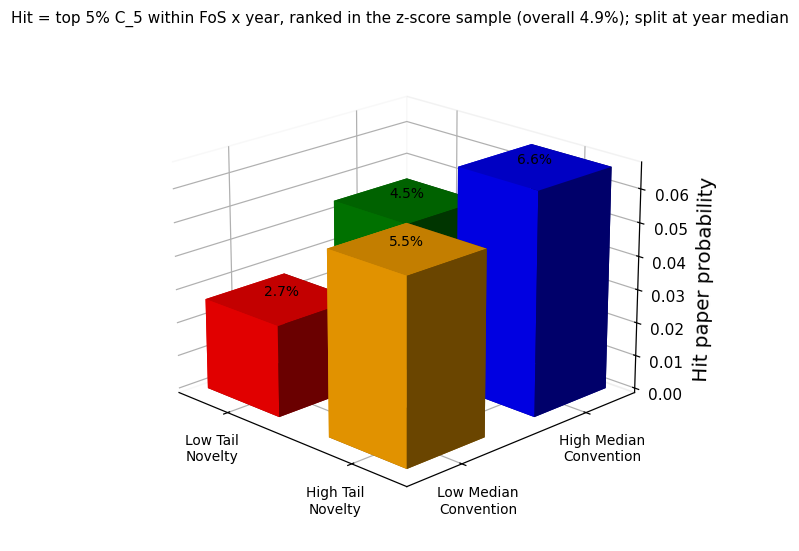

CPU times: user 1min 27s, sys: 11.5 s, total: 1min 38s
Wall time: 40.5 s


In [4]:
%%time
if not HAS_Z:
    print('paper_z_score.parquet not present yet -> run paper_z_score, then re-run this cell.')
else:
    # median conventionality = Z_median ; tail novelty = low Z_10pct (more negative = more novel).
    # HIT IS RE-RANKED INSIDE THE SAMPLE: C_5 from paper_citation, percent_rank() within
    # (FoS, year) over the papers that have a z-score, hit = cpct >= HIT_PCTL. The corpus-wide
    # pctl_call is carried along only to report what it would have given (see the section note).
    HIT_PCTL = 0.95
    # Each axis is split at the median of the paper's OWN publication-year cohort, computed in
    # DuckDB and joined back, so a pooled median never enters. year and FoS come from
    # paper_hit_probability: paper_z_score.parquet has neither. A paper with no row in
    # paper_citation has no forward citations, hence coalesce(C_5, 0).
    q = f'''
    WITH s AS (
      SELECT h.year, h.FoS, z.Z_median, z.Z_10pct, h.pctl_call, coalesce(c.C_5, 0) AS C_5
      FROM read_parquet('{ZS}') z
      JOIN read_parquet('{HIT}') h USING (paper_id)
      LEFT JOIN read_parquet('{CIT}') c USING (paper_id)
      WHERE z.Z_median IS NOT NULL AND z.Z_10pct IS NOT NULL
        AND h.year IS NOT NULL AND h.FoS IS NOT NULL),
    r AS (
      SELECT year, Z_median, Z_10pct, pctl_call, C_5,
             percent_rank() OVER (PARTITION BY FoS, year ORDER BY C_5) AS cpct
      FROM s),
    m AS (
      SELECT year, median(Z_median) AS med_conv_y, median(Z_10pct) AS med_nov_y
      FROM r GROUP BY year)
    SELECT r.year, r.Z_median, r.Z_10pct, r.C_5, r.cpct, r.pctl_call, m.med_conv_y, m.med_nov_y
    FROM r JOIN m USING (year)
    '''
    d = con.execute(q).fetchdf()
    hi_conv = d['Z_median'] >= d['med_conv_y']          # high median conventionality, within its year
    hi_nov = d['Z_10pct'] <= d['med_nov_y']             # high tail novelty (lower Z = more novel), within its year
    hit = d['cpct'] >= HIT_PCTL                         # top 5% C_5 within FoS x year, ranked in this sample
    cells = {('LowConv', 'LowNov'): (~hi_conv) & (~hi_nov), ('LowConv', 'HighNov'): (~hi_conv) & hi_nov,
             ('HighConv', 'LowNov'): hi_conv & (~hi_nov), ('HighConv', 'HighNov'): hi_conv & hi_nov}
    P4 = {k: hit[v].mean() for k, v in cells.items()}
    N4 = {k: int(v.sum()) for k, v in cells.items()}
    H4 = {k: int(hit[v].sum()) for k, v in cells.items()}
    # The per-year cut points, so the split is auditable. Cell counts should be near-equal
    # within every year by construction; pooled they still are, which a pooled cut would not give.
    thr = (d.groupby('year')[['med_conv_y', 'med_nov_y']].first()
             .rename(columns={'med_conv_y': 'split_Z_median', 'med_nov_y': 'split_Z_10pct'}))
    thr['n'] = d.groupby('year').size()
    thr['hit_rate'] = hit.groupby(d['year']).mean()
    print(f'{len(d):,} papers, {int(d.year.min())}-{int(d.year.max())}, split at each year\'s own median; '
          f'hit_rate = share with cpct >= {HIT_PCTL} (re-ranked within FoS x year in this sample):')
    display(thr.round(4))
    # Per-quadrant hit probability. `ratio_to_overall` is P(hit | quadrant) / P(hit); the overall
    # rate is ~5% by construction, so 1.0 is the baseline and Uzzi's HighConv|HighNov cell should
    # sit clearly above it.
    overall = hit.mean()
    old = (d['pctl_call'] >= HIT_PCTL).mean()
    tab = pd.DataFrame({'n': N4, 'hits': H4, 'hit_probability': P4})
    tab.index = pd.MultiIndex.from_tuples(tab.index, names=['convention', 'novelty'])
    tab['ratio_to_overall'] = tab['hit_probability'] / overall
    print(f'hit = top {round((1 - HIT_PCTL) * 100)}% by C_5 within FoS x year, ranked among these {len(d):,} papers; '
          f'overall hit rate {overall:.4f} ({int(hit.sum()):,} / {len(d):,})')
    print(f'[diagnostic] corpus-wide pctl_call >= {HIT_PCTL} would flag {old:.4f} of this sample as hits -- '
          f'that is the base-population mismatch this cell avoids')
    display(tab.style.format({'n': '{:,}', 'hits': '{:,}', 'hit_probability': '{:.4%}', 'ratio_to_overall': '{:.2f}x'}))
    print('hit probability per quadrant:')
    for (a, b), p in P4.items():
        print(f'  {a:>8} | {b:<7}  P(hit) = {p:.4%}   n = {N4[(a, b)]:>12,}   hits = {H4[(a, b)]:>10,}   {p / overall:.2f}x overall')
    # 3D bars: x = novelty (low,high), y = convention (low,high)
    from mpl_toolkits.mplot3d import Axes3D  # noqa
    fig = plt.figure(figsize=(9, 6)); ax = fig.add_subplot(projection='3d')
    xpos = np.array([0, 1, 0, 1]); ypos = np.array([0, 0, 1, 1]); zpos = np.zeros(4)
    dz = [P4[('LowConv', 'LowNov')], P4[('LowConv', 'HighNov')], P4[('HighConv', 'LowNov')], P4[('HighConv', 'HighNov')]]
    ax.bar3d(xpos, ypos, zpos, 0.6, 0.6, dz, color=['red', 'orange', 'green', 'blue'], zsort='average')
    for x0, y0, z0 in zip(xpos, ypos, dz):
        ax.text(x0 + 0.3, y0 + 0.3, z0, f'{z0:.1%}', ha='center', va='bottom', fontsize=9)
    ax.set_xticks([0.3, 1.3]); ax.set_xticklabels(['Low Tail\nNovelty', 'High Tail\nNovelty'], fontsize=9)
    ax.set_yticks([0.3, 1.3]); ax.set_yticklabels(['Low Median\nConvention', 'High Median\nConvention'], fontsize=9)
    ax.set_zlabel('Hit paper probability', fontsize=13); ax.view_init(20, -45)
    ax.set_title(f'Hit = top {round((1 - HIT_PCTL) * 100)}% C_5 within FoS x year, ranked in the z-score sample '
                 f'(overall {overall:.1%}); split at year median', fontsize=10)
    for pane in (ax.xaxis, ax.yaxis, ax.zaxis): pane.pane.fill = False
    V.save('3')


In [5]:
d

,year,Z_median,Z_10pct,C_5,cpct,pctl_call,med_conv_y,med_nov_y
0,1980,596.904855,416.985692,2,0.701104,0.894197,39.317253,1.610552
1,1980,23.774131,-3.110248,2,0.701104,0.917856,39.317253,1.610552
2,1980,106.333333,31.666667,2,0.701104,0.907939,39.317253,1.610552
3,1980,6.633250,-1.387775,2,0.701104,0.983149,39.317253,1.610552
4,1980,24.401188,8.637913,2,0.701104,0.996046,39.317253,1.610552
...,...,...,...,...,...,...,...,...
41214335,2000,812.363648,812.363648,2,0.282557,0.490942,60.165290,0.740396
41214336,2000,28.027617,-1.925630,2,0.282557,0.580842,60.165290,0.740396
41214337,2000,2.584652,-14.906050,2,0.282557,0.820426,60.165290,0.740396
41214338,2000,16.636890,-5.486469,2,0.282557,0.668705,60.165290,0.740396


In [6]:
HAS_Z

True

## 3b. Atypicality 2x2 - SciSciNet atypicality (Atyp_Median_Z x Atyp_10pct_Z)

Same 2×2 on SciSciNet's own atypicality scores. As in section 3, high/low on each axis is the
paper's position relative to the median of its **own publication year**, not the pooled median.


In [7]:
%%time
from mpl_toolkits.mplot3d import Axes3D  # noqa

def plot_2x2(zmed, znov, hit, title, zlabel='Hit paper probability', year=None):
    # zmed = median conventionality (higher = more conventional); znov = tail novelty score (LOWER = more novel)
    # year: if given, each axis is split at the median of the paper's OWN year cohort (as in
    # section 3); if None, at the pooled median -- kept only for a caller with a single cohort.
    zmed = np.asarray(zmed, float); znov = np.asarray(znov, float); hit = np.asarray(hit, float)
    m = np.isfinite(zmed) & np.isfinite(znov) & np.isfinite(hit)
    if year is not None:
        year = np.asarray(year, float); m &= np.isfinite(year); year = year[m]
    zmed, znov, hit = zmed[m], znov[m], hit[m]
    if year is None:
        cut_med, cut_nov = np.median(zmed), np.median(znov)
    else:
        _g = pd.DataFrame({'y': year, 'zm': zmed, 'zn': znov}).groupby('y')
        cut_med = _g['zm'].transform('median').to_numpy()
        cut_nov = _g['zn'].transform('median').to_numpy()
    hc = zmed >= cut_med                    # high median conventionality (within year if year given)
    hn = znov <= cut_nov                    # high tail novelty (lower Z = more novel)
    cells = {('LowConv', 'LowNov'): (~hc) & (~hn), ('LowConv', 'HighNov'): (~hc) & hn,
             ('HighConv', 'LowNov'): hc & (~hn), ('HighConv', 'HighNov'): hc & hn}
    P4 = {k: hit[v].mean() for k, v in cells.items()}
    fig = plt.figure(figsize=(9, 6)); ax = fig.add_subplot(projection='3d')
    xpos = np.array([0, 1, 0, 1]); ypos = np.array([0, 0, 1, 1]); zpos = np.zeros(4)
    dz = [P4[('LowConv', 'LowNov')], P4[('LowConv', 'HighNov')], P4[('HighConv', 'LowNov')], P4[('HighConv', 'HighNov')]]
    ax.bar3d(xpos, ypos, zpos, 0.6, 0.6, dz, color=['red', 'orange', 'green', 'blue'], zsort='average')
    ax.set_xticks([0.3, 1.3]); ax.set_xticklabels(['Low Tail\nNovelty', 'High Tail\nNovelty'], fontsize=9)
    ax.set_yticks([0.3, 1.3]); ax.set_yticklabels(['Low Median\nConvention', 'High Median\nConvention'], fontsize=9)
    ax.set_zlabel(zlabel, fontsize=12); ax.set_title(title, fontsize=11); ax.view_init(20, -45)
    for pane in (ax.xaxis, ax.yaxis, ax.zaxis): pane.pane.fill = False
    plt.tight_layout(); V.save('3b')
    print(title, '-> hit prob per cell:', {f'{a}|{b}': round(p, 4) for (a, b), p in P4.items()})

CPU times: user 11 μs, sys: 0 ns, total: 11 μs
Wall time: 13.8 μs


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

<timed exec>:31: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
/project/jevans/Dawoon/Science of Science/validation/val_common.py:96: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


  [fig] paper_validation_3b.jpg + .pdf  (600 dpi)


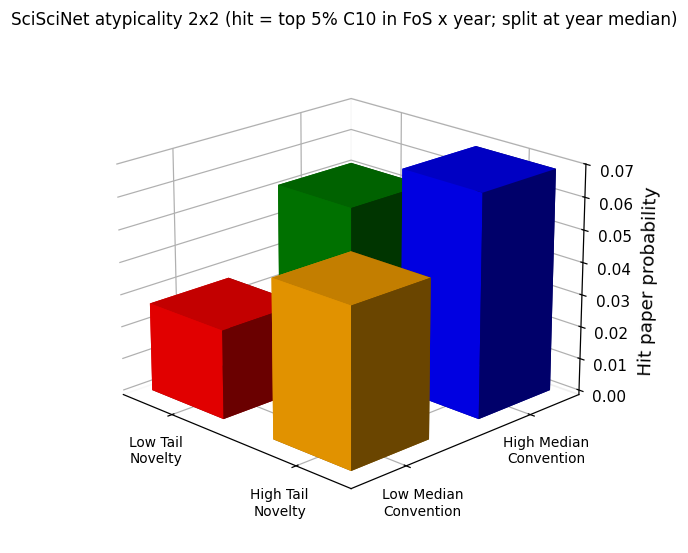

SciSciNet atypicality 2x2 (hit = top 5% C10 in FoS x year; split at year median) -> hit prob per cell: {'LowConv|LowNov': 0.0273, 'LowConv|HighNov': 0.0487, 'HighConv|LowNov': 0.0518, 'HighConv|HighNov': 0.0686}
CPU times: user 21.6 s, sys: 3.62 s, total: 25.2 s
Wall time: 31.2 s


In [8]:
%%time
FEG = V.SCISCINET_FOS
# The field names below are spelled out literally (Atyp_Median_Z, Atyp_10pct_Z, C10, FoS_rep,
# FoS_0, year). A release that spells them differently must not take down 3c-7b, which do not
# depend on this file -- hence the guard rather than a bare query.
Q3B = f'''
WITH b AS (
  SELECT Atyp_Median_Z am, Atyp_10pct_Z ap, C10,
         coalesce(FoS_rep, split_part(FoS_0,';',1)) fos, year
  FROM read_parquet('{FEG}')
  WHERE Atyp_Median_Z IS NOT NULL AND Atyp_10pct_Z IS NOT NULL AND year BETWEEN 1950 AND 2010)
SELECT am, ap, year, percent_rank() OVER (PARTITION BY fos, year ORDER BY C10) cpct FROM b
'''
try:
    dsn = con.execute(Q3B).fetchdf()
    hit = (dsn['cpct'] >= 0.95).astype(float).values
    plot_2x2(dsn['am'].values, dsn['ap'].values, hit,
             'SciSciNet atypicality 2x2 (hit = top 5% C10 in FoS x year; split at year median)',
             year=dsn['year'].values)
    del dsn
except Exception as e:
    print(f'[skip 3b] {str(e)[:220]}')


## 3c. Agreement with SciSciNet — correlation of the same metrics computed two ways

`sciscinet_papers_fos_feg.parquet` carries SciSciNet's own disruption, atypicality and
citation counts for the same papers. This section joins them to ours on the paper id and
reports how far the two agree.

It is a **convergent-validity check, not a ground truth**. SciSciNet is built on MAG with its
own reference set, window conventions and field partition; this pipeline is built on the
OpenAlex 2026-01 snapshot. A high rank correlation says the two implementations recover the
same ordering of papers. A low one localises where they diverge — which is the useful
outcome either way, because it says which metric is sensitive to the citation graph
underneath it.

Reported per metric: **Pearson** (linear agreement on the raw values) and **Spearman**
(agreement on the ordering, which is what almost every downstream use actually depends on).

In [9]:
%%time
# Column names differ across SciSciNet releases, so nothing here is hard-coded: the schema is
# read first and only the metric pairs that exist on BOTH sides are compared.
import pyarrow.parquet as _pq

FEG = V.SCISCINET_FOS
cmp3c, data3c, N_SAMPLE = pd.DataFrame(), {}, 3_000_000

def _sciscinet_schema(path):
    """Column names, or [] if the file is absent or still being copied."""
    try:
        cols = _pq.ParquetFile(path).schema_arrow.names
        print(f'SciSciNet columns ({len(cols)}): {cols}')
        return cols
    except Exception as e:
        print(f'[skip 3c] cannot read {path}: {str(e)[:140]}')
        return []

def _pick(cols, *aliases):
    low = {c.lower(): c for c in cols}
    for a in aliases:
        if a.lower() in low:
            return low[a.lower()]
    return None

def _join_key(path, cols):
    """SQL expression turning SciSciNet's id into our 'W…' paper_id.

    Ours is the OpenAlex 'W…' string; SciSciNet's is the bare MAG integer. In this snapshot
    the OpenAlex id of a MAG-sourced work IS 'W' + the MAG id, so the two are the same number
    with a prefix. The matched-row counts printed below are the check on that assumption --
    if they come out near zero the ids are not comparable and nothing after it means anything.
    """
    sid = _pick(cols, 'PaperID', 'paper_id', 'MAG_id', 'magid', 'id')
    if sid is None:
        print(f'[skip 3c] no id column among {cols}')
        return None, None
    is_text = str(_pq.ParquetFile(path).schema_arrow.field(sid).type).startswith(
        ('string', 'large_string'))
    key = (f"CASE WHEN starts_with(s.{sid}, 'W') THEN s.{sid} ELSE concat('W', s.{sid}) END"
           if is_text else f"concat('W', CAST(s.{sid} AS BIGINT))")
    print(f'join key: {sid} ({"text" if is_text else "integer"}) -> {key}')
    return sid, key

sn_cols = _sciscinet_schema(FEG)
SN_ID, SN_KEY = _join_key(FEG, sn_cols) if sn_cols else (None, None)

if SN_KEY:
    # (label, SciSciNet column, our parquet, our column, log-scale in the scatter)
    # Windows are matched where both sides define one: SciSciNet's *_y5 against our *_5.
    SPEC = [
        ('Disruption (5y)',    _pick(sn_cols, 'disruption', 'Disruption'), DISR, 'CD_5',     False),
        ('Disruption (all)',   _pick(sn_cols, 'disruption', 'Disruption'), DISR, 'CD_all',   False),
        ('Atypicality median', _pick(sn_cols, 'Atyp_Median_Z'),            ZS,   'Z_median', False),
        ('Atypicality 10pct',  _pick(sn_cols, 'Atyp_10pct_Z'),             ZS,   'Z_10pct',  False),
        ('Citations 5y',       _pick(sn_cols, 'C5', 'C_5'),                CIT,  'C_5',      True),
        ('Citations 10y',      _pick(sn_cols, 'C10', 'C_10'),              CIT,  'C_10',     True),
        ('Citations total',    _pick(sn_cols, 'cited_by_count'),           META, 'cited_by_count', True),
        ('Reference count',    _pick(sn_cols, 'reference_count'),          META, 'ref_count',      True),
        ('F 5y (foundation)',  _pick(sn_cols, 'f_y5', 'F'),                DISR, 'F_5',      False),
        ('E 5y (extension)',   _pick(sn_cols, 'e_y5', 'E'),                DISR, 'E_5',      False),
        ('G 5y (generalizn)',  _pick(sn_cols, 'g_y5', 'G'),                DISR, 'G_5',      False),
        ('Sleeping beauty B',  _pick(sn_cols, 'SB_B'),                     SB,   'SB_B',     True),
        ('Sleeping beauty T',  _pick(sn_cols, 'SB_T'),                     SB,   'SB_T',     False),
    ]
    SPEC = [s for s in SPEC if s[1] is not None]
    print(f'comparable metrics: {[s[0] for s in SPEC]}')

    # SAMPLE, not the full 349M-row join: a correlation over a few million random pairs is
    # already far tighter than the systematic difference between the two pipelines, and the
    # full join is hours of I/O for digits that do not move.
    rows = []
    for label, sn_col, our_fp, our_col, logscale in SPEC:
        q = (f'SELECT s."{sn_col}" AS sn, o."{our_col}" AS ours '
             f"FROM read_parquet('{FEG}') s "
             f"JOIN read_parquet('{our_fp}') o ON o.paper_id = {SN_KEY} "
             f'WHERE s."{sn_col}" IS NOT NULL AND o."{our_col}" IS NOT NULL '
             f'USING SAMPLE {N_SAMPLE} ROWS')
        try:
            dd = con.execute(q).fetchdf()
        except Exception as e:
            print(f'  [skip] {label}: {str(e)[:130]}')
            continue
        dd = dd.replace([np.inf, -np.inf], np.nan).dropna(subset=['sn', 'ours'])
        if len(dd) < 1000:
            print(f'  [skip] {label}: only {len(dd):,} matched rows')
            continue
        pear = float(np.corrcoef(dd['sn'], dd['ours'])[0, 1])
        # Spearman == Pearson on ranks; done this way to keep 3M rows off scipy.
        spear = float(np.corrcoef(dd['sn'].rank(), dd['ours'].rank())[0, 1])
        rows.append({'metric': label, 'n': len(dd), 'pearson': pear, 'spearman': spear})
        data3c[label] = (dd, logscale)
        print(f'  {label:<20} n={len(dd):>9,}  pearson {pear:+.4f}  spearman {spear:+.4f}')

    cmp3c = pd.DataFrame(rows)
    if len(cmp3c):
        display(cmp3c.round(4))


SciSciNet columns (39): ['paperid', 'doi', 'year', 'date', 'doctype', 'cited_by_count', 'is_retracted', 'reference_count', 'citation_count', 'C3', 'C5', 'C10', 'disruption', 'Atyp_Median_Z', 'Atyp_10pct_Z', 'Atyp_Pairs', 'WSB_mu', 'WSB_sigma', 'WSB_Cinf', 'SB_B', 'SB_T', 'team_size', 'institution_count', 'patent_count', 'newsfeed_count', 'nct_count', 'nih_count', 'nsf_count', 'FoS_0', 'FoS_rep', 'gen_pub_year', 'up_refer_count', 'citation_count_y5', 'e_count_y5', 'f_count_y5', 'g_count_y5', 'e_y5', 'f_y5', 'g_y5']
join key: paperid (text) -> CASE WHEN starts_with(s.paperid, 'W') THEN s.paperid ELSE concat('W', s.paperid) END
comparable metrics: ['Disruption (5y)', 'Disruption (all)', 'Atypicality median', 'Atypicality 10pct', 'Citations 5y', 'Citations 10y', 'Citations total', 'Reference count', 'F 5y (foundation)', 'E 5y (extension)', 'G 5y (generalizn)', 'Sleeping beauty B', 'Sleeping beauty T']


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  Disruption (5y)      n=1,280,662  pearson +0.1114  spearman +0.6240


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  Disruption (all)     n=1,412,932  pearson +0.1055  spearman +0.6753


...

  Sleeping beauty B    n=2,896,312  pearson +0.0017  spearman +0.4847


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  Sleeping beauty T    n=2,895,799  pearson +0.4208  spearman +0.4104


,metric,n,pearson,spearman
0,Disruption (5y),1280662,0.1114,0.6240
1,Disruption (all),1412932,0.1055,0.6753
2,Atypicality median,2654917,0.4755,0.7220
3,Atypicality 10pct,2677282,0.5974,0.6787
4,Citations 5y,3000000,0.9891,0.9670
5,Citations 10y,3000000,0.9938,0.9693
6,Citations total,3000000,0.9942,0.9800
7,Reference count,3000000,0.9935,0.9939
8,F 5y (foundation),1042529,0.7513,0.7821
9,E 5y (extension),1042755,0.8181,0.8098


CPU times: user 22min 3s, sys: 3min 50s, total: 25min 53s
Wall time: 17min 48s


/scratch/local/jobs/57892922/ipykernel_2130080/390486429.py:11: RuntimeWarning: divide by zero encountered in log10
  x, y = np.log10(x + 1), np.log10(y + 1)
/scratch/local/jobs/57892922/ipykernel_2130080/390486429.py:11: RuntimeWarning: invalid value encountered in log10
  x, y = np.log10(x + 1), np.log10(y + 1)


  [fig] paper_validation_3c.jpg + .pdf  (600 dpi)


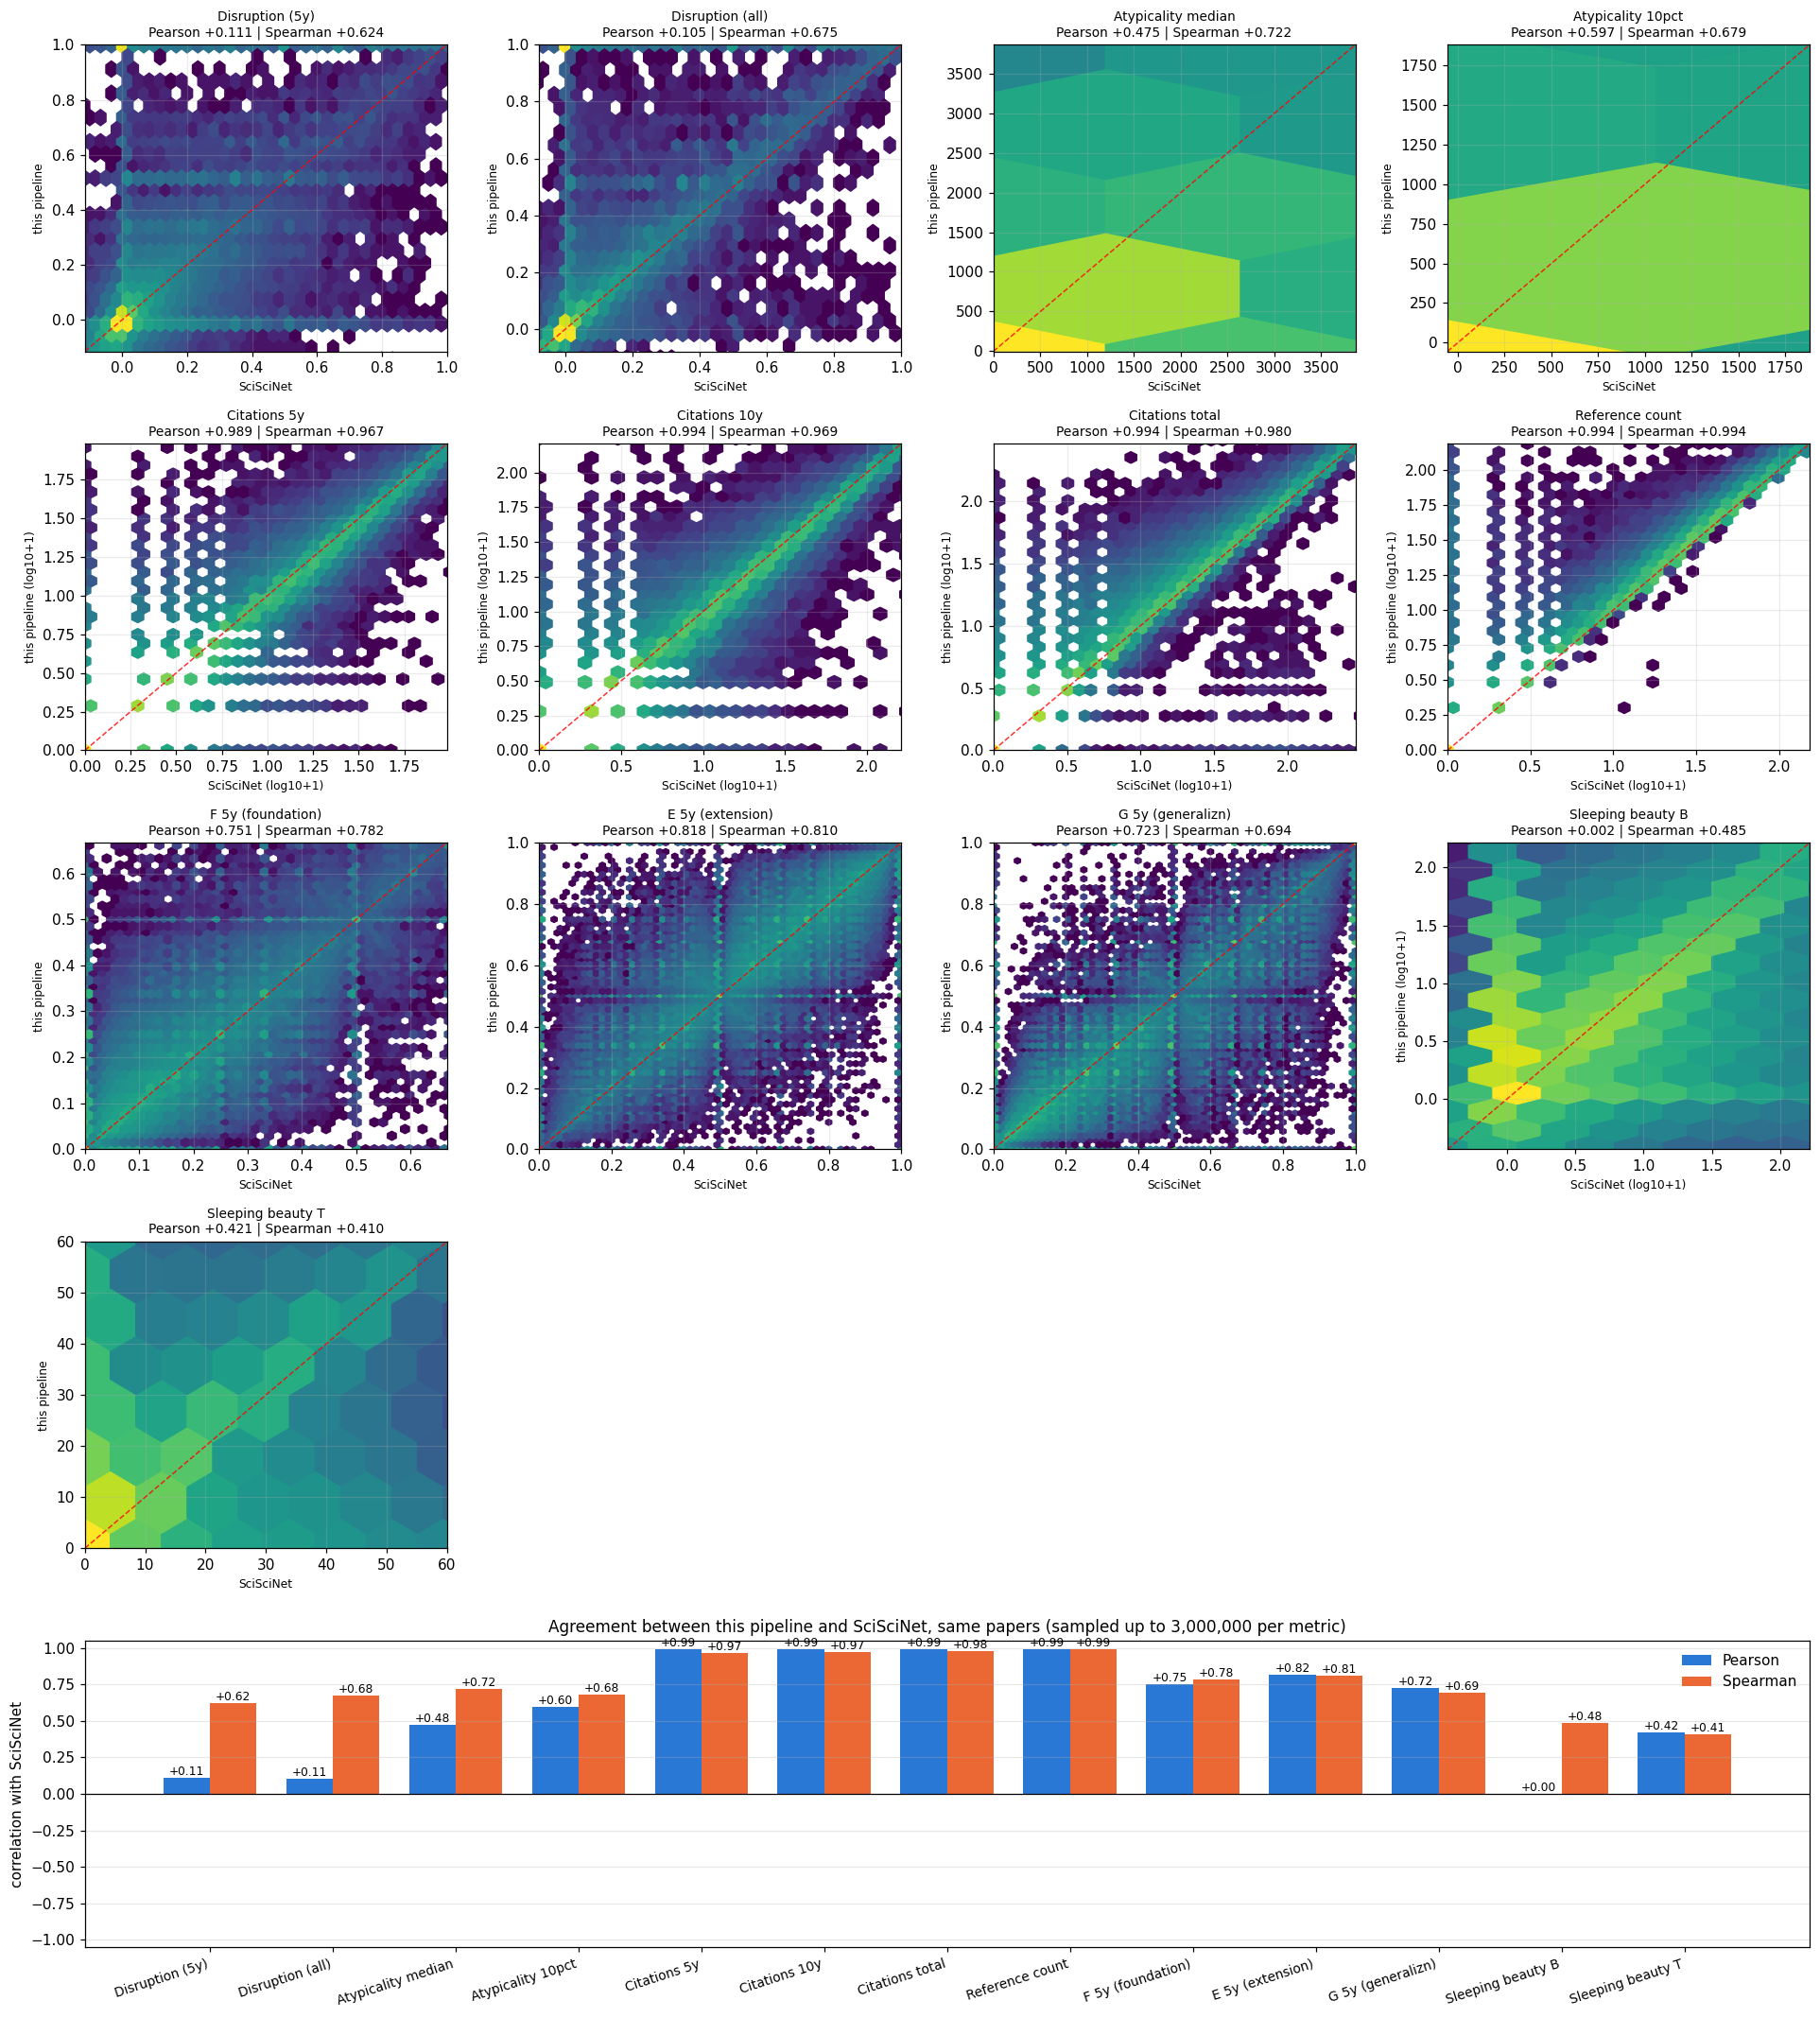

In [10]:

if len(cmp3c) == 0:
    print('[skip 3c figure] nothing comparable')
else:
    k = len(data3c)
    ncol = min(4, k); nrow = int(np.ceil(k / ncol)) + 1
    fig = plt.figure(figsize=(4.4 * ncol, 3.9 * nrow))
    for i, (label, (d3, logscale)) in enumerate(data3c.items()):
        ax = fig.add_subplot(nrow, ncol, i + 1)
        x, y = d3['sn'].values, d3['ours'].values
        if logscale:
            x, y = np.log10(x + 1), np.log10(y + 1)
        ax.hexbin(x, y, gridsize=60, bins='log', mincnt=1, cmap='viridis')
        lo, hi = np.nanpercentile(np.concatenate([x, y]), [0.5, 99.5])
        ax.plot([lo, hi], [lo, hi], 'r--', lw=1, alpha=0.8)      # y = x, perfect agreement
        ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
        rr_ = cmp3c.loc[cmp3c.metric == label]
        if not len(rr_):
            continue
        r = rr_.iloc[0]
        ax.set_title(f"{label}\nPearson {r.pearson:+.3f} | Spearman {r.spearman:+.3f}", fontsize=9)
        ax.set_xlabel('SciSciNet' + (' (log10+1)' if logscale else ''), fontsize=8)
        ax.set_ylabel('this pipeline' + (' (log10+1)' if logscale else ''), fontsize=8)
        ax.grid(alpha=0.25)
    # summary bars across the bottom row
    ax = fig.add_subplot(nrow, 1, nrow)
    xs = np.arange(len(cmp3c)); w = 0.38
    ax.bar(xs - w/2, cmp3c.pearson,  w, label='Pearson',  color='#2a78d6')
    ax.bar(xs + w/2, cmp3c.spearman, w, label='Spearman', color='#eb6834')
    for j, rr in cmp3c.iterrows():
        ax.text(j - w/2, rr.pearson,  f'{rr.pearson:+.2f}',  ha='center',
                va='bottom' if rr.pearson  >= 0 else 'top', fontsize=8)
        ax.text(j + w/2, rr.spearman, f'{rr.spearman:+.2f}', ha='center',
                va='bottom' if rr.spearman >= 0 else 'top', fontsize=8)
    ax.set_xticks(xs); ax.set_xticklabels(cmp3c.metric, rotation=18, ha='right', fontsize=9)
    ax.axhline(0, color='k', lw=0.8); ax.set_ylim(-1.05, 1.05)
    ax.set_ylabel('correlation with SciSciNet', fontsize=10)
    ax.set_title('Agreement between this pipeline and SciSciNet, same papers '
                 f'(sampled up to {N_SAMPLE:,} per metric)', fontsize=11)
    ax.legend(frameon=False); ax.grid(axis='y', alpha=0.3)
    V.save('3c')


## 4. Atypicality Z-score CDF (reference style: 10th-pct & Median)

In [11]:
%%time
import matplotlib.ticker as _tk
MIN_N = 1000

def find_nearest(array, value):
    array = np.asarray(array)
    return int((np.abs(array - value)).argmin())

def plot_atyp_cdf(df_, col_10pct, col_median, title,
                  ylabel='CDF of journal papers',
                  label1=r'$10^{\rm th}$ percentile $Z$-score', label2=r'Median $Z$-score'):
    """CDF of Atyp Z-scores at 24 thresholds: 8 neg (-2^8..-2^1) | 0 | 15 pos (2^1..2^15)."""
    plt.rcParams['text.usetex'] = False
    label_x1 = np.array([(x + 1) for x in range(8)])[::-1]
    label_x2 = np.array([0])
    label_x3 = np.array([(x + 1) for x in range(15)])
    label_x = np.concatenate((label_x1, label_x2, label_x3))
    atyp_x = np.arange(1, 25)

    def myticks(x, pos):
        i = int(round(x)) - 1
        if i < 0 or i >= len(label_x): return ''
        v = label_x[i]
        if x < 9:
            return r'$-2^{%d}$' % v if int(round(x)) % 2 != 0 else ''
        elif x == 9:
            return r'$0$'
        else:
            return r'$2^{%d}$' % v if int(round(x)) % 2 != 0 else ''

    def compute_cdf(col):
        if col not in df_.columns:
            print(f'  [skip] {col} not in data'); return None
        vals = df_[col].replace([np.inf, -np.inf], np.nan).dropna().values
        if len(vals) < MIN_N: return None
        zs = np.sort(vals)
        pos1 = np.array([find_nearest(zs, -2 ** (x + 1)) for x in range(8)])[::-1]
        pos2 = np.array([find_nearest(zs, 0)])
        pos3 = np.array([find_nearest(zs, 2 ** (x + 1)) for x in range(15)])
        return np.concatenate((pos1, pos2, pos3)) / len(zs)

    pct_p = compute_cdf(col_10pct); pct_p2 = compute_cdf(col_median)
    if pct_p is None and pct_p2 is None:
        print(f'  [skip plot] no data for {col_10pct!r} / {col_median!r}'); return
    fig, ax = plt.subplots(dpi=150)
    if pct_p is not None:
        ax.plot(atyp_x, pct_p, 'o-', ms=9, markeredgewidth=2, lw=2, label=label1, markerfacecolor='none', alpha=0.7)
    if pct_p2 is not None:
        ax.plot(atyp_x, pct_p2, 'o-', ms=9, markeredgewidth=2, lw=2, label=label2, markerfacecolor='none', alpha=0.7)
    ax.xaxis.set_major_locator(_tk.IndexLocator(base=1, offset=0))
    ax.yaxis.set_minor_locator(_tk.IndexLocator(base=0.1, offset=0))
    ax.tick_params(axis='x', labelsize=12); ax.tick_params(axis='y', labelsize=12)
    ax.set_xlabel(r'$Z$-score', fontsize=16); ax.set_ylabel(ylabel, fontsize=16)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.xaxis.set_major_formatter(_tk.FuncFormatter(myticks))
    ax.set_title(title, fontsize=12)
    ax.legend(loc=0, numpoints=1, fontsize=12, frameon=False)
    plt.tight_layout(); V.save('4')

CPU times: user 11 μs, sys: 0 ns, total: 11 μs
Wall time: 12.9 μs


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  [fig] paper_validation_4.jpg + .pdf  (600 dpi)


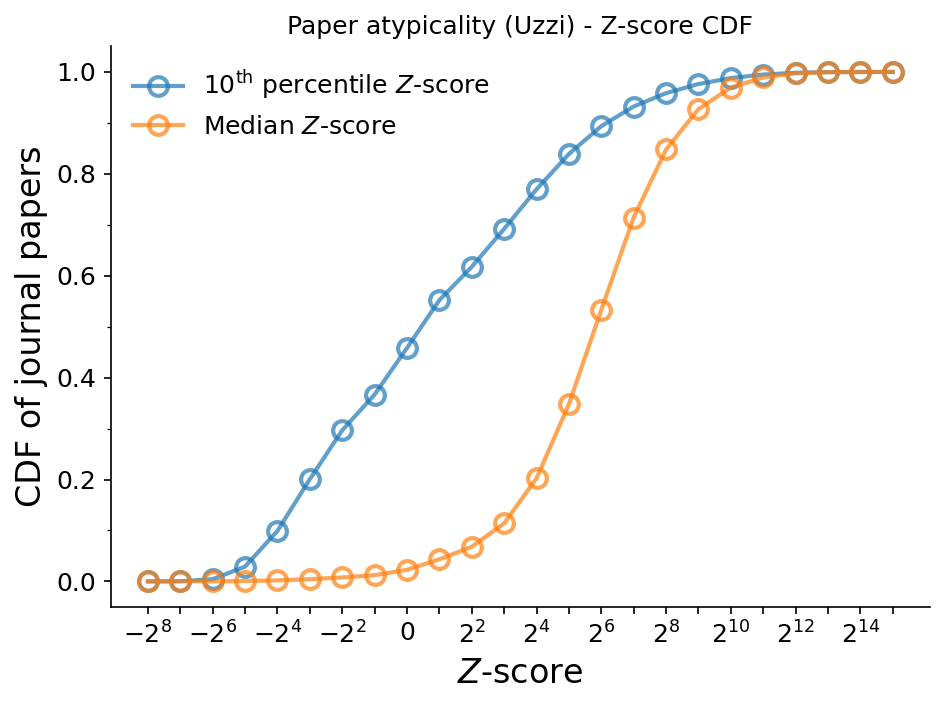

           Z_median       Z_10pct
count  4.142504e+07  4.142504e+07
mean   1.802220e+02  5.409900e+01
std    5.172240e+02  3.878500e+02
min   -8.129790e+02 -8.129790e+02
25%    2.068500e+01 -5.709000e+00
50%    5.670800e+01  8.340000e-01
75%    1.500100e+02  1.334900e+01
max    2.094563e+05  2.094563e+05
CPU times: user 13.8 s, sys: 6.1 s, total: 19.9 s
Wall time: 21.7 s


In [12]:
%%time
if not HAS_Z:
    print('paper_z_score.parquet not present yet -> skipped.')
else:
    dz = con.execute(f"SELECT Z_median, Z_10pct FROM read_parquet('{ZS}')").fetchdf()
    plot_atyp_cdf(dz, 'Z_10pct', 'Z_median', 'Paper atypicality (Uzzi) - Z-score CDF')
    print(dz[['Z_median', 'Z_10pct']].describe().round(3).to_string())

## 5. Sleeping Beauty validation (B / T, B vs impact, top sleeping beauties)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  [fig] paper_validation_5.jpg + .pdf  (600 dpi)


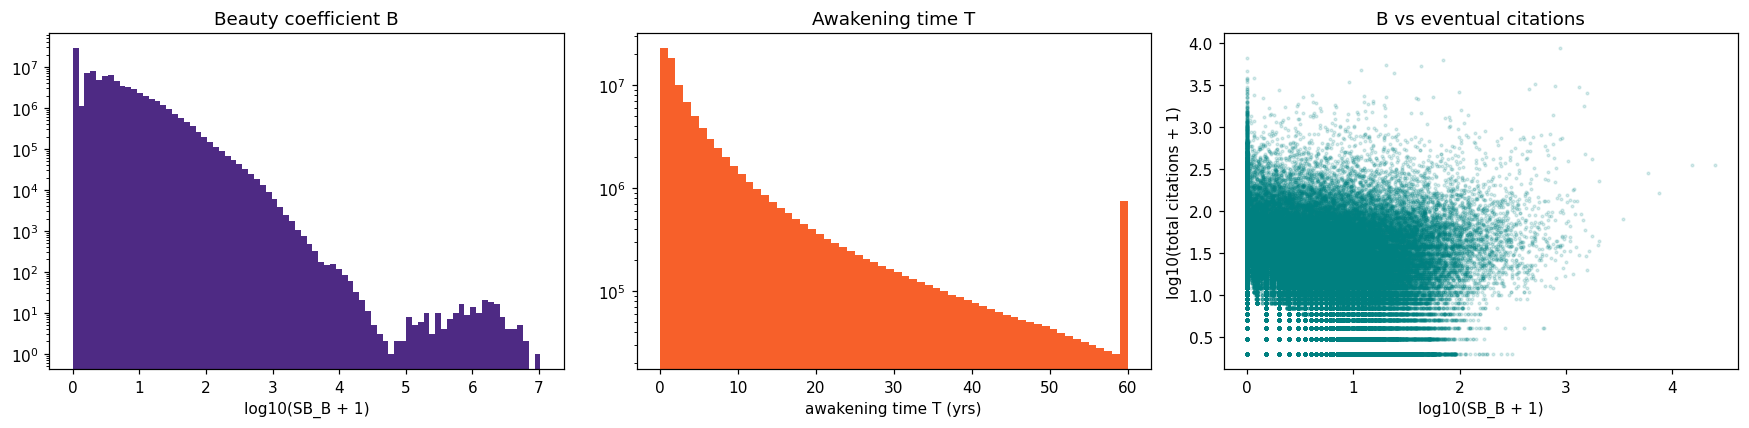

Top sleeping beauties:


,paper_id,SB_B,SB_T,n_cite
0,W2007442728,10541546.0,24,1033592
1,W1978608505,6743336.5,17,1282814
2,W2053472650,6306505.5,24,663667
3,W1994173793,5259485.5,22,547190
4,W2131038366,5209826.0,39,334049
5,W1969035145,5082060.5,15,1260028
6,W2036929842,4870302.0,23,547195
7,W2000536338,4743740.0,12,1033568
8,W2055167159,4597735.5,30,334018
9,W2023185708,4499379.5,11,826421


SB_B: mean 9.53 median 1.11 | frac B>0 69.0%
CPU times: user 15.2 s, sys: 1.9 s, total: 17.1 s
Wall time: 15.8 s


In [13]:
%%time
sb = con.execute(f"SELECT SB_B, SB_T, n_cite FROM read_parquet('{SB}')").fetchdf()
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].hist(np.log10(sb['SB_B'].clip(lower=0) + 1), bins=80, color='#4E2A84')
ax[0].set_yscale('log'); ax[0].set_xlabel('log10(SB_B + 1)'); ax[0].set_title('Beauty coefficient B')
ax[1].hist(sb['SB_T'].clip(0, 60), bins=60, color='#F7602A')
ax[1].set_yscale('log'); ax[1].set_xlabel('awakening time T (yrs)'); ax[1].set_title('Awakening time T')
s = sb.sample(min(200000, len(sb)), random_state=0)
ax[2].scatter(np.log10(s['SB_B'].clip(lower=0) + 1), np.log10(s['n_cite'] + 1), s=3, alpha=0.15, color='teal')
ax[2].set_xlabel('log10(SB_B + 1)'); ax[2].set_ylabel('log10(total citations + 1)'); ax[2].set_title('B vs eventual citations')
plt.tight_layout(); V.save('5')
top = con.execute(f'''SELECT s.paper_id, s.SB_B, s.SB_T, s.n_cite
  FROM read_parquet('{SB}') s ORDER BY s.SB_B DESC LIMIT 10''').fetchdf()
print('Top sleeping beauties:'); display(top)
print(f"SB_B: mean {sb.SB_B.mean():.2f} median {sb.SB_B.median():.2f} | frac B>0 {(sb.SB_B>0).mean()*100:.1f}%")

## 6. Cumulative citation trajectory — convexity for HIT top-1% papers (FoS level-0)

Restricted to **hit top-1% papers** (`pctl_c5 >= 0.99`, top 1% by 5-yr citations within FoS × year), using
**all** such papers (no sampling). Per-paper **cumulative** paper→paper (`p2p`) curves are min–max scaled;
the **convexity index** = 1 − mean(normalised citation age) (`<0.5` convex = late burst; `>0.5` concave).
Computed out-of-core with DuckDB over the 452M-row trend. Field breakdown = **FoS level-0**.

In [14]:
%%time
RED = '#d62728'; NB = 20; GX = np.arange(NB + 1) / NB
TREND = P('paper_citation_trend.parquet'); HIT = P('paper_hit_probability.parquet')
con.execute(f"CREATE OR REPLACE TEMP VIEW hit1 AS SELECT paper_id FROM read_parquet('{HIT}') WHERE pctl_c5 >= 0.99")
AGG = (f"SELECT paper_id, sum(p2p) tot, max(yrs_since_pub) span FROM read_parquet('{TREND}') "
       "WHERE paper_id IN (SELECT paper_id FROM hit1) GROUP BY paper_id HAVING sum(p2p)>=10 AND max(yrs_since_pub)>=5")
per = con.execute(f'''WITH agg AS ({AGG})
  SELECT t.paper_id, a.tot, a.span, 1 - sum(t.p2p*(t.yrs_since_pub::double/a.span))/a.tot AS cvx
  FROM read_parquet('{TREND}') t JOIN agg a USING (paper_id) GROUP BY t.paper_id, a.tot, a.span''').fetchdf()
fos = con.execute(f"SELECT paper_id, coalesce(FoS_rep, split_part(FoS_0,';',1)) FoS "
                  f"FROM read_parquet('{P('paper_metadata.parquet')}') WHERE paper_id IN (SELECT paper_id FROM hit1)").fetchdf()
sbb = con.execute(f"SELECT paper_id, SB_B FROM read_parquet('{SB}') WHERE paper_id IN (SELECT paper_id FROM hit1)").fetchdf()
per = per.merge(fos, on='paper_id', how='left').merge(sbb, on='paper_id', how='left')
per['shape'] = np.where(per['cvx'] < 0.5, 'convex', 'concave')
Npap = len(per); print(f'HIT top-1% papers with trajectory (no sample): {Npap:,}')

def mean_traj(id_series=None):
    where = ''
    if id_series is not None:
        con.register('flt', pd.DataFrame({'paper_id': id_series.values})); where = 'JOIN flt USING (paper_id)'
    q = f'''WITH agg AS ({AGG}), j AS (
      SELECT (t.yrs_since_pub::double/a.span) nt, t.p2p v, a.tot, t.paper_id
      FROM read_parquet('{TREND}') t JOIN agg a USING (paper_id) {where})
    SELECT least(floor(nt*{NB}), {NB}) b, sum(v::double/tot) w FROM j GROUP BY b ORDER BY b'''
    h = con.execute(q).fetchdf()
    N = len(id_series) if id_series is not None else Npap
    wv = np.zeros(NB + 1); wv[h['b'].astype(int).values] = h['w'].values
    return np.cumsum(wv) / N

def cvx_area(m): return np.trapz(m, GX)
overall = mean_traj()
hi_ids = per.loc[per['SB_B'] >= per['SB_B'].quantile(0.90), 'paper_id']
hitraj = mean_traj(hi_ids)
print(f'overall trajectory convexity index {cvx_area(overall):.3f} | per-item mean convexity index {per.cvx.mean():.3f} | {(per.cvx<0.5).mean()*100:.1f}% convex')

# ---- section 6a works on the top 1% by SLEEPING BEAUTY, not by citations ----------------
# `per` above is the citation hit top-1% and stays as it is, because section 6b reports on
# it. This is a second, disjoint selection: the documents whose citation history is most
# delayed, which is what a trajectory figure is actually about.
SB_Q = 0.99
sb_all = con.execute(f"SELECT paper_id, SB_B FROM read_parquet('{SB}') WHERE SB_B IS NOT NULL").fetchdf()
SB_CUT = sb_all['SB_B'].quantile(SB_Q)
sb1_ids = sb_all.loc[sb_all['SB_B'] >= SB_CUT, 'paper_id']
con.register('sb1', pd.DataFrame({'paper_id': sb1_ids.values}))
con.execute('CREATE OR REPLACE TEMP VIEW sb1v AS SELECT paper_id FROM sb1')

AGG_SB = (f"SELECT paper_id, sum(p2p) tot, max(yrs_since_pub) span FROM read_parquet('{TREND}') "
          "WHERE paper_id IN (SELECT paper_id FROM sb1v) GROUP BY paper_id "
          "HAVING sum(p2p)>=10 AND max(yrs_since_pub)>=5")
per_sb = con.execute(f'''WITH agg AS ({AGG_SB})
  SELECT t.paper_id, a.tot, a.span,
         1 - sum(t.p2p*(t.yrs_since_pub::double/a.span))/a.tot AS cvx
  FROM read_parquet('{TREND}') t JOIN agg a USING (paper_id)
  GROUP BY t.paper_id, a.tot, a.span''').fetchdf()
fos_sb = con.execute(
    f"SELECT paper_id, coalesce(FoS_rep, split_part(FoS_0,';',1)) FoS "
    f"FROM read_parquet('{P('paper_metadata.parquet')}') "
    f"WHERE paper_id IN (SELECT paper_id FROM sb1v)").fetchdf()
per_sb = per_sb.merge(fos_sb, on='paper_id', how='left').merge(sb_all, on='paper_id', how='left')
Nsb = len(per_sb)


def mean_traj_sb(id_series=None):
    where = ''
    if id_series is not None:
        con.register('fltsb', pd.DataFrame({'paper_id': id_series.values}))
        where = 'JOIN fltsb USING (paper_id)'
    q = f'''WITH agg AS ({AGG_SB}), j AS (
      SELECT (t.yrs_since_pub::double/a.span) nt, t.p2p v, a.tot, t.paper_id
      FROM read_parquet('{TREND}') t JOIN agg a USING (paper_id) {where})
    SELECT least(floor(nt*{NB}), {NB}) b, sum(v::double/tot) w FROM j GROUP BY b ORDER BY b'''
    h = con.execute(q).fetchdf()
    N = len(id_series) if id_series is not None else Nsb
    wv = np.zeros(NB + 1); wv[h['b'].astype(int).values] = h['w'].values
    return np.cumsum(wv) / N


def t_half(m):
    """Normalised time by which half the citations have arrived.

    Reported instead of the number this panel used to report. That per-item quantity is
    1 - (citation-weighted mean normalised time): not an area under anything, and the label
    invited reading it as a classifier score. It survives as `cvx`, the convexity index, and
    t-half says the same thing directly -- above 0.5 the citations arrive late, which is what
    a convex cumulative curve looks like, and it can be read straight off the y = 0.5 line."""
    return float(np.interp(0.5, m, GX))


overall_sb = mean_traj_sb()
print(f'top {(1-SB_Q)*100:.0f}% by SB_B: cut B >= {SB_CUT:.2f}, '
      f'{len(sb1_ids):,} papers, {Nsb:,} with a usable trajectory')
print(f'  t-half {t_half(overall_sb):.3f}   '
      f'{(per_sb.cvx < 0.5).mean()*100:.1f}% convex (per-item index < 0.5)')


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

top 1% by SB_B: cut B >= 79.50, 883,951 papers, 783,288 with a usable trajectory
  t-half 0.741   90.1% convex (per-item index < 0.5)
CPU times: user 6min 32s, sys: 22 s, total: 6min 54s
Wall time: 3min 8s


### 6a. Overall trajectory + convexity-index distribution + high-SB (within hit top-1%)

  [fig] paper_validation_6a.jpg + .pdf  (600 dpi)


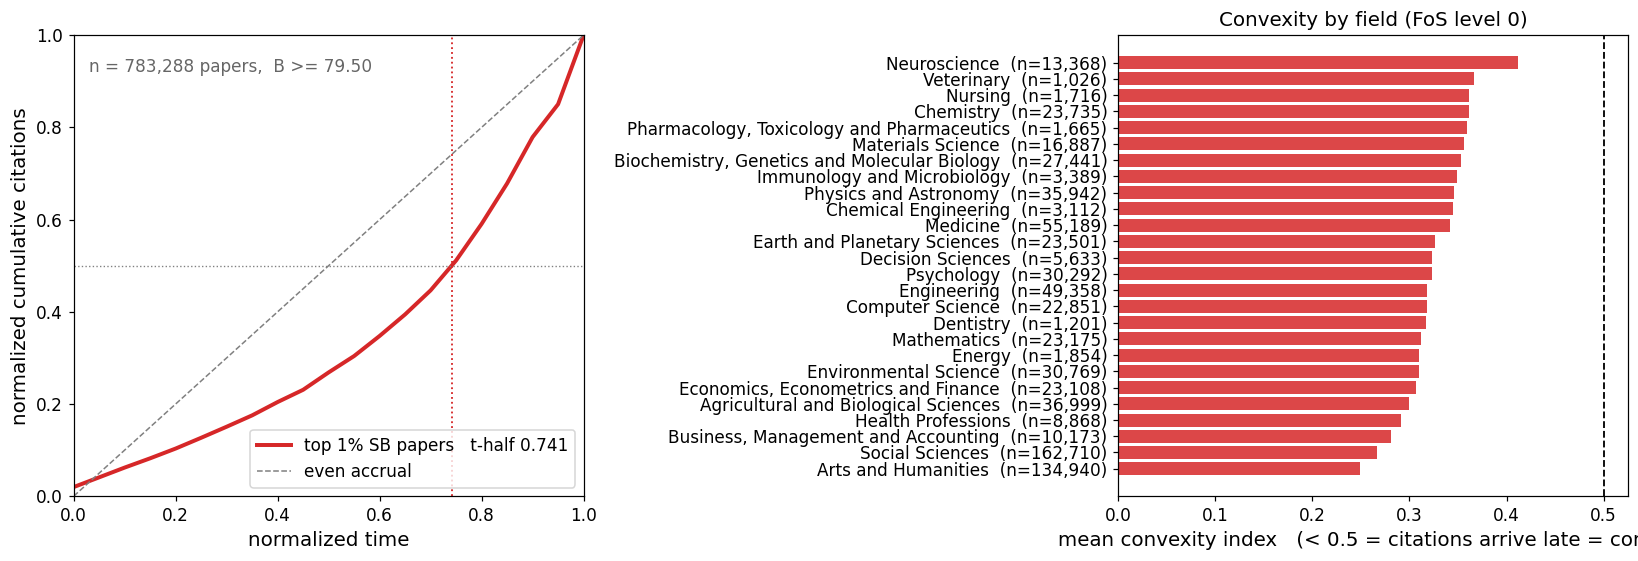


top 1% SB papers: convexity index by field (n >= 30)
                                              mean_cvx       n
FoS                                                           
Arts and Humanities                             0.2494  134940
Social Sciences                                 0.2670  162710
Business, Management and Accounting             0.2810   10173
Health Professions                              0.2908    8868
Agricultural and Biological Sciences            0.2993   36999
Economics, Econometrics and Finance             0.3072   23108
Environmental Science                           0.3096   30769
Energy                                          0.3102    1854
Mathematics                                     0.3118   23175
Dentistry                                       0.3171    1201
Computer Science                                0.3176   22851
Engineering                                     0.3179   49358
Psychology                                      0.3229   30292
D

In [15]:
# =========================== LABELS AND FONT SIZES ===========================
XLAB_A, YLAB_A = 'normalized time', 'normalized cumulative citations'
XLAB_B = 'mean convexity index   (< 0.5 = citations arrive late = convex)'
LEG_A  = 'top 1% SB papers   t-half {th:.3f}'
LEG_REF = 'even accrual'
ANNOT_A = 'n = {n:,} papers,  B >= {cut:.2f}'
TITLE_B = 'Convexity by field (FoS level 0)'
MIN_GRP = 30                      # fields with fewer papers than this are dropped
FS_LAB, FS_TICK, FS_LEG, FS_ANNOT = 13, 11, 11, 11
FIGSIZE = (15, 5.2)
# =============================================================================
fig, ax = plt.subplots(1, 2, figsize=FIGSIZE)

# --- panel A: the mean cumulative trajectory of the top 1% by SB ---
ax[0].plot(GX, overall_sb, color=RED, lw=2.6, label=LEG_A.format(th=t_half(overall_sb)))
ax[0].plot([0, 1], [0, 1], color='gray', ls='--', lw=1, label=LEG_REF)
ax[0].axhline(.5, color='gray', ls=':', lw=.9)
ax[0].axvline(t_half(overall_sb), color=RED, ls=':', lw=1.2)
ax[0].set_xlabel(XLAB_A, fontsize=FS_LAB); ax[0].set_ylabel(YLAB_A, fontsize=FS_LAB)
ax[0].set_xlim(0, 1); ax[0].set_ylim(0, 1)
ax[0].tick_params(labelsize=FS_TICK); ax[0].legend(loc='lower right', fontsize=FS_LEG)
ax[0].text(.03, .95, ANNOT_A.format(n=Nsb, cut=SB_CUT), transform=ax[0].transAxes,
           va='top', fontsize=FS_ANNOT, color='#666')

# --- panel B: convexity by field, within that same selection ---
byf = (per_sb.dropna(subset=['FoS'])
             .groupby('FoS')['cvx'].agg(['mean', 'size']))
byf = byf[byf['size'] >= MIN_GRP].sort_values('mean')
cols = np.where(byf['mean'] < 0.5, RED, '#4c72b0')
ax[1].barh(range(len(byf)), byf['mean'], color=cols, alpha=.85)
ax[1].axvline(0.5, color='k', ls='--', lw=1.2)
ax[1].set_yticks(range(len(byf)))
ax[1].set_yticklabels([f'{f}  (n={int(n):,})' for f, n in zip(byf.index, byf['size'])],
                      fontsize=FS_TICK)
ax[1].set_xlabel(XLAB_B, fontsize=FS_LAB)
ax[1].set_title(TITLE_B, fontsize=FS_LAB)
ax[1].tick_params(axis='x', labelsize=FS_TICK)
plt.tight_layout(); V.save('6a')

print(f'\ntop 1% SB papers: convexity index by field (n >= {MIN_GRP})')
print(byf.rename(columns={'mean': 'mean_cvx', 'size': 'n'}).round(4).to_string())

### 6b. Convex vs concave (hit top-1%) — by field (FoS level-0) and group properties

  [fig] paper_validation_6b.jpg + .pdf  (600 dpi)


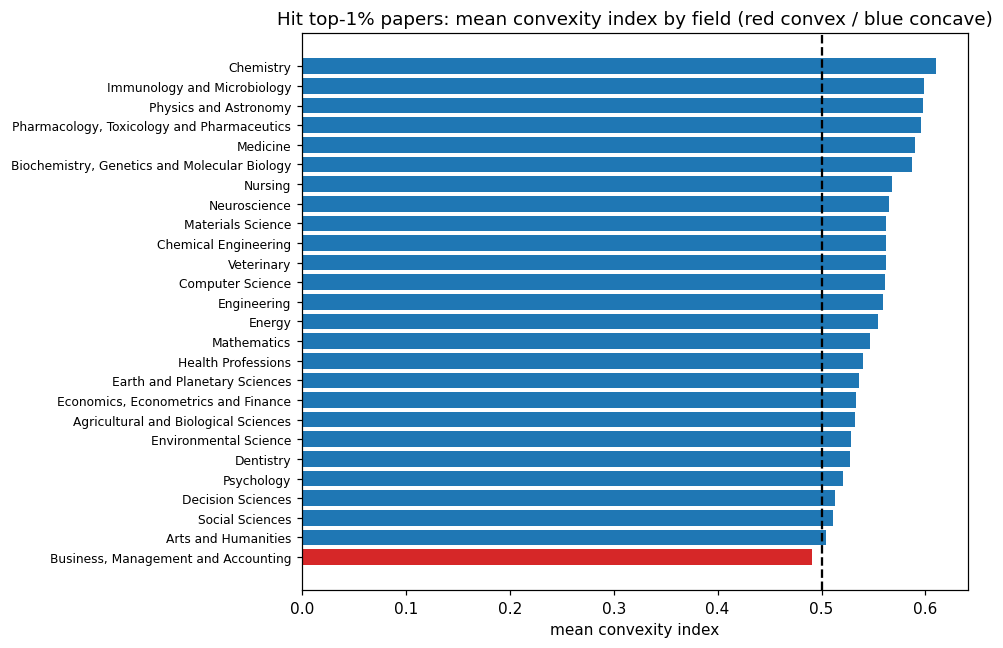

overall (hit top-1%): {'convex%': 35.3, 'concave%': 64.7, 'mean_cvx': 0.553}
\nconvex vs concave group properties:
               n  mean_cvx  mean_citations  mean_SB_B
shape                                                
concave  1247732      0.61          245.69   3.330000
convex    681266      0.44          397.27  23.469999
\nmean convexity index / %convex by field:


,mean_cvx,pct_convex,n
FoS,,,
"Business, Management and Accounting",0.491,60.220,46971
Arts and Humanities,0.504,49.816,121832
Social Sciences,0.511,48.849,255444
Decision Sciences,0.513,48.313,17931
Psychology,0.521,47.659,47934
Dentistry,0.527,45.809,5691
Environmental Science,0.529,45.086,88670
Agricultural and Biological Sciences,0.533,46.197,118180
"Economics, Econometrics and Finance",0.533,40.147,53240


Spearman(SB_B, convexity index) = -0.139  (negative = higher SB -> more convex)
done — paper hit-top-1% convexity analysis rendered inline.


In [16]:
pct_convex = (per['cvx'] < 0.5).mean() * 100
byf = per.dropna(subset=['FoS']).groupby('FoS').agg(
    mean_cvx=('cvx', 'mean'), pct_convex=('cvx', lambda x: (x < 0.5).mean() * 100), n=('cvx', 'size'))
byf = byf[byf['n'] >= 30].sort_values('mean_cvx')
fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#d62728' if a < 0.5 else '#1f77b4' for a in byf['mean_cvx']]
ax.barh(range(len(byf)), byf['mean_cvx'], color=colors)
ax.set_yticks(range(len(byf))); ax.set_yticklabels(byf.index, fontsize=8)
ax.axvline(0.5, color='k', ls='--'); ax.set_xlabel('mean convexity index')
ax.set_title('Hit top-1% papers: mean convexity index by field (red convex / blue concave)')
plt.tight_layout(); V.save('6b')
print('overall (hit top-1%):', {'convex%': round(pct_convex, 1), 'concave%': round(100 - pct_convex, 1), 'mean_cvx': round(per.cvx.mean(), 3)})
print('\\nconvex vs concave group properties:')
print(per.groupby('shape').agg(n=('cvx', 'size'), mean_cvx=('cvx', 'mean'),
      mean_citations=('tot', 'mean'), mean_SB_B=('SB_B', 'mean')).round(2).to_string())
print('\\nmean convexity index / %convex by field:'); display(byf.round(3))
sp = pd.DataFrame({'sb': per['SB_B'], 'cvx': per['cvx']}).replace([np.inf, -np.inf], np.nan).dropna()
print(f'Spearman(SB_B, convexity index) = {sp.sb.rank().corr(sp.cvx.rank()):+.3f}  (negative = higher SB -> more convex)')
print('done — paper hit-top-1% convexity analysis rendered inline.')

### 6c. Trajectory by field — hit top-1%

§6b reports the hit top-1% as one bar per field. This draws the trajectory those numbers
summarise: one panel per FoS level-0 field, mean cumulative citation curve. A curve below the
diagonal is convex — citations arrive late.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  [fig] paper_validation_6c.jpg + .pdf  (600 dpi)


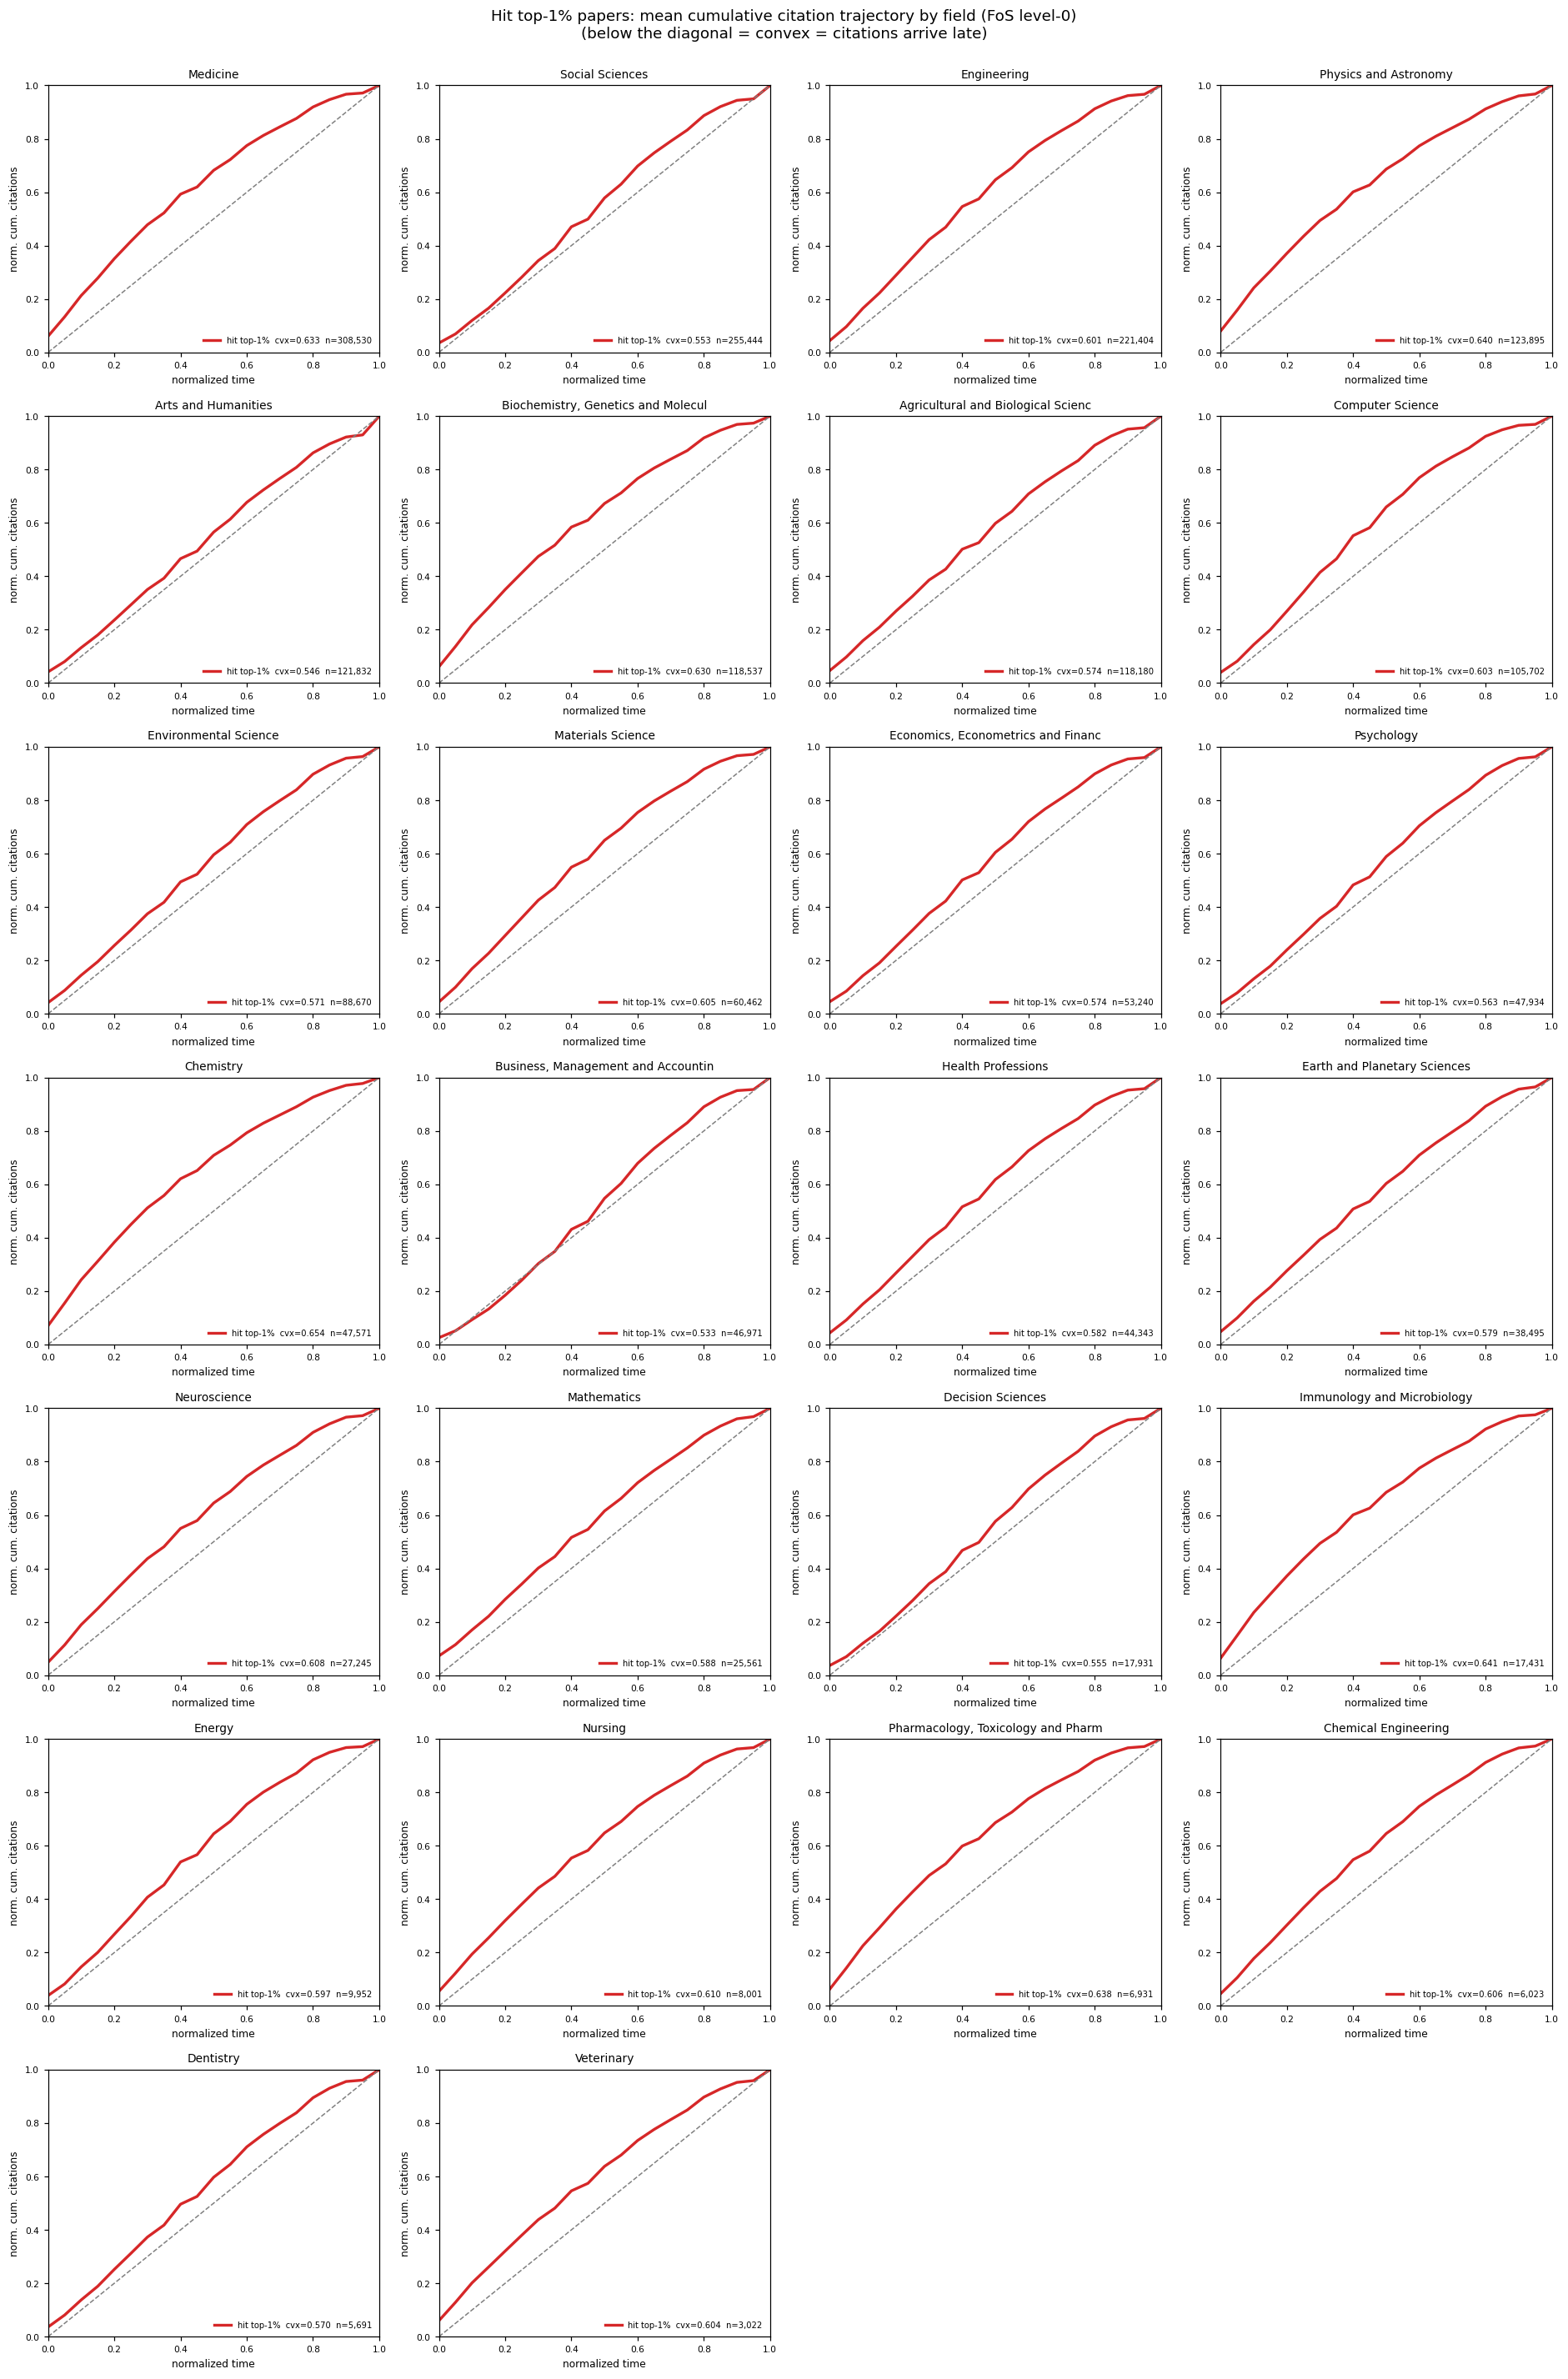

,n,trajectory_cvx
FoS,,
"Business, Management and Accounting",46971,0.5331
Arts and Humanities,121832,0.5456
Social Sciences,255444,0.5529
Decision Sciences,17931,0.5550
Psychology,47934,0.5633
Dentistry,5691,0.5696
Environmental Science,88670,0.5710
Agricultural and Biological Sciences,118180,0.5741
"Economics, Econometrics and Finance",53240,0.5743


CPU times: user 2min 17s, sys: 6.71 s, total: 2min 24s
Wall time: 46.4 s


In [17]:
%%time
# Shared machinery for 6c-6e. Section 6 above reports the hit top-1% in aggregate and as
# a bar per field; these cells draw the trajectory itself per field, and then drop the
# hit restriction so the corpus shape can be read too.
METAP6 = P('paper_metadata.parquet')
FOS_SQL = (f"SELECT paper_id, coalesce(FoS_rep, split_part(FoS_0,';',1)) FoS "
           f"FROM read_parquet('{METAP6}') WHERE coalesce(FoS_rep, FoS_0) IS NOT NULL")
MIN_FOS = 500        # fields with fewer papers than this are not drawn

# The all-papers aggregation groups a 584M-row trend by paper_id. The connection was
# opened with 16 GB in cell 1, which would spill this to disk for hours; raise it (the
# job runs on a 250 GB node). Raising a limit is safe for the later sections.
con.execute("SET memory_limit='200GB'")

def _agg6(hit_only):
    where = "WHERE paper_id IN (SELECT paper_id FROM hit1) " if hit_only else ""
    return (f"SELECT paper_id, sum(p2p) tot, max(yrs_since_pub) span "
            f"FROM read_parquet('{TREND}') {where}"
            f"GROUP BY paper_id HAVING sum(p2p)>=10 AND max(yrs_since_pub)>=5")

def traj_overall6(hit_only):
    agg = _agg6(hit_only)
    h = con.execute(f"WITH agg AS ({agg}), j AS ("
        f"SELECT least(floor((t.yrs_since_pub::double/a.span)*{NB}),{NB}) b, "
        f"t.p2p::double/a.tot w FROM read_parquet('{TREND}') t JOIN agg a USING (paper_id)) "
        f"SELECT b, sum(w) w FROM j GROUP BY b ORDER BY b").fetchdf()
    n = con.execute(f"WITH agg AS ({agg}) SELECT count(*) FROM agg").fetchone()[0]
    wv = np.zeros(NB + 1); wv[h['b'].astype(int).values] = h['w'].values
    return np.cumsum(wv) / n, int(n)

def traj_by_fos(hit_only):
    agg = _agg6(hit_only)
    h = con.execute(f"WITH agg AS ({agg}), fos AS ({FOS_SQL}), j AS ("
        f"SELECT fos.FoS f, least(floor((t.yrs_since_pub::double/a.span)*{NB}),{NB}) b, "
        f"t.p2p::double/a.tot w FROM read_parquet('{TREND}') t "
        f"JOIN agg a USING (paper_id) JOIN fos USING (paper_id)) "
        f"SELECT f, b, sum(w) w FROM j GROUP BY f, b ORDER BY f, b").fetchdf()
    cnt = con.execute(f"WITH agg AS ({agg}), fos AS ({FOS_SQL}) "
        f"SELECT FoS f, count(*) n FROM agg JOIN fos USING (paper_id) GROUP BY FoS"
        ).fetchdf().set_index('f')['n']
    out = {}
    for f, g in h.groupby('f'):
        if cnt.get(f, 0) < MIN_FOS:
            continue
        wv = np.zeros(NB + 1); wv[g['b'].astype(int).values] = g['w'].values
        out[f] = (np.cumsum(wv) / cnt[f], int(cnt[f]))
    return out

def cvx_by_fos(hit_only):
    # Aggregated in SQL: the all-papers cohort is tens of millions of rows, and only
    # the per-field summary is needed, so it never has to reach pandas.
    agg = _agg6(hit_only)
    return con.execute(f"WITH agg AS ({agg}), fos AS ({FOS_SQL}), c AS ("
        f"SELECT t.paper_id, 1 - sum(t.p2p*(t.yrs_since_pub::double/a.span))/a.tot cvx "
        f"FROM read_parquet('{TREND}') t JOIN agg a USING (paper_id) "
        f"GROUP BY t.paper_id, a.tot, a.span) "
        f"SELECT fos.FoS f, count(*) n, avg(c.cvx) mean_cvx, "
        f"avg(CASE WHEN c.cvx<0.5 THEN 100.0 ELSE 0 END) pct_convex "
        f"FROM c JOIN fos USING (paper_id) GROUP BY fos.FoS ORDER BY mean_cvx").fetchdf()

def panel_grid6(a, b, title, section_label, la='hit top-1%', lb='all papers'):
    # `b` is None when only one series is drawn (section 6c passes it that way). The loop
    # below already guards for that; this line did not, so set(None) raised TypeError and
    # the section never produced a figure -- it has no stored output in any past run.
    a = a or {}; b = b or {}
    keys = sorted(set(a) | set(b), key=lambda k: -(b.get(k) or a.get(k))[1])
    ncol = 4; nrow = int(np.ceil(len(keys) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.3 * ncol, 3.7 * nrow), squeeze=False)
    for ax_, f in zip(axes.flat, keys):
        for src, lab, c in [(a, la, RED), (b, lb, '#4c72b0')]:
            if src is None or f not in src:
                continue
            y, n = src[f]
            ax_.plot(GX, y, color=c, lw=2.2, label=f'{lab}  cvx={cvx_area(y):.3f}  n={n:,}')
        ax_.plot([0, 1], [0, 1], color='gray', ls='--', lw=1)
        ax_.set_xlim(0, 1); ax_.set_ylim(0, 1)
        ax_.set_title(str(f)[:34], fontsize=9)
        ax_.set_xlabel('normalized time', fontsize=8)
        ax_.set_ylabel('norm. cum. citations', fontsize=8)
        ax_.legend(loc='lower right', fontsize=6.5, frameon=False)
        ax_.tick_params(labelsize=7)
    for ax_ in axes.flat[len(keys):]:
        ax_.set_visible(False)
    fig.suptitle(title, fontsize=12, y=1.0)
    V.save(section_label)

fos_hit = traj_by_fos(True)
panel_grid6(fos_hit, None,
            'Hit top-1% papers: mean cumulative citation trajectory by field (FoS level-0)\n'
            '(below the diagonal = convex = citations arrive late)', '6c')
t6 = pd.DataFrame([{'FoS': f, 'n': n, 'trajectory_cvx': cvx_area(y)}
                   for f, (y, n) in fos_hit.items()]).set_index('FoS').sort_values('trajectory_cvx')
display(t6.round(4))


### 6d. ALL papers — overall

§6 measures only the hit top-1%. That cohort is selected on citation count, which is the same
quantity whose arrival time the convexity index measures, so its trajectory shape cannot be
read as the shape of the corpus. This is the corpus, keeping only the filter the metric needs
to exist (>= 10 citations, span >= 5 years), with the hit top-1% curve drawn alongside so the
size of the selection effect is visible.

In [ ]:
%%time
# ---- ALL papers, no hit restriction ---------------------------------------------
# Section 6 measures only the hit top-1%. That cohort is selected on citation count,
# which is the same quantity whose arrival time the convexity index measures, so its
# trajectory shape cannot be read as the corpus shape. This is the corpus, with only
# the filter the metric needs to exist (>=10 citations, span >=5 years).
overall_all6, n_all6 = traj_overall6(False)
byf_all = cvx_by_fos(False)
byf_hit = cvx_by_fos(True)
print(f'ALL papers with a trajectory : {n_all6:,}   (hit top-1% cohort: {Npap:,})')
print(f'trajectory convexity index   : all {cvx_area(overall_all6):.3f} | '
      f'hit top-1% {cvx_area(overall):.3f}')

samp = con.execute(f"WITH agg AS ({_agg6(False)}) "
    f"SELECT 1 - sum(t.p2p*(t.yrs_since_pub::double/a.span))/a.tot cvx "
    f"FROM read_parquet('{TREND}') t JOIN agg a USING (paper_id) "
    f"GROUP BY t.paper_id, a.tot, a.span USING SAMPLE 2000000 ROWS").fetchdf()
print(f'per-paper convexity index (2M sample): mean {samp.cvx.mean():.3f}, '
      f'{100*(samp.cvx<0.5).mean():.1f}% convex')

fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
ax[0].plot(GX, overall_all6, color='#4c72b0', lw=2.6,
           label=f'all papers  cvx={cvx_area(overall_all6):.3f}  n={n_all6:,}')
ax[0].plot(GX, overall, color=RED, lw=2.6,
           label=f'hit top-1%  cvx={cvx_area(overall):.3f}  n={Npap:,}')
ax[0].plot([0, 1], [0, 1], color='gray', ls='--', lw=1, label='even accrual')
ax[0].set_xlim(0, 1); ax[0].set_ylim(0, 1)
ax[0].set_title('Mean cumulative trajectory: all papers vs hit top-1%')
ax[0].set_xlabel('normalized time'); ax[0].set_ylabel('normalized cumulative citations')
ax[0].legend(loc='lower right', fontsize=9)
ax[1].hist(samp.cvx.values, bins=120, color='#4c72b0')
ax[1].axvline(0.5, color='k', ls='--', lw=1.2); ax[1].axvline(samp.cvx.mean(), color=RED, lw=1.5)
ax[1].set_title('ALL papers: per-paper convexity index (2M sample)')
ax[1].set_xlabel('convexity index  (<0.5 convex)'); ax[1].set_ylabel('papers')
bb = byf_all[byf_all['n'] >= MIN_FOS].sort_values('mean_cvx')
colors = ['#d62728' if a < 0.5 else '#1f77b4' for a in bb['mean_cvx']]
ax[2].barh(range(len(bb)), bb['mean_cvx'], color=colors)
ax[2].set_yticks(range(len(bb)))
ax[2].set_yticklabels([f'{str(f)[:26]}  (n={int(n):,})' for f, n in zip(bb['f'], bb['n'])], fontsize=7)
ax[2].axvline(0.5, color='k', ls='--'); ax[2].set_xlabel('mean convexity index')
ax[2].set_title('ALL papers: convexity index by field')
V.save('6d')

m = bb[['f', 'n', 'mean_cvx', 'pct_convex']].rename(
        columns={'mean_cvx': 'all_mean_cvx', 'pct_convex': 'all_pct_convex', 'n': 'n_all'}).merge(
    byf_hit[['f', 'n', 'mean_cvx']].rename(
        columns={'mean_cvx': 'hit_mean_cvx', 'n': 'n_hit'}), on='f', how='left')
m['delta_hit_minus_all'] = m['hit_mean_cvx'] - m['all_mean_cvx']
display(m.set_index('f').round(4))


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

ALL papers with a trajectory : 32,947,264   (hit top-1% cohort: 1,928,998)
trajectory convexity index   : all 0.559 | hit top-1% 0.595


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

### 6e. ALL papers — trajectory by field

§6c for the whole corpus, with the hit top-1% curve overlaid in each panel.

In [ ]:
%%time
fos_all = traj_by_fos(False)
panel_grid6(fos_hit, fos_all,
            'Mean cumulative citation trajectory by field (FoS level-0): '
            'hit top-1% vs all papers\n(below the diagonal = convex = citations arrive late)', '6e')

rows = []
for f in sorted(set(fos_hit) & set(fos_all)):
    rows.append({'FoS': f, 'n_all': fos_all[f][1], 'cvx_all': cvx_area(fos_all[f][0]),
                 'n_hit': fos_hit[f][1], 'cvx_hit': cvx_area(fos_hit[f][0])})
cf = pd.DataFrame(rows).set_index('FoS')
cf['delta'] = cf['cvx_hit'] - cf['cvx_all']
display(cf.sort_values('cvx_all').round(4))
print('cvx_all vs cvx_hit is a selection contrast, not a field property: the hit cohort is')
print('picked on citation count, the same quantity whose arrival time the index measures.')


## 7. Yearly-trend convexity — Disruption / F / E / G / ni / nj / nk (overall & by FoS)

Same min–max + convexity-index test applied to the **time trend** of each metric (mean value by publication year):
`<0.5` **convex** (accelerating / late upturn), `>0.5` **concave** (early rise then flattening). Computed
overall and per **FoS level-0** field, from `paper_disruption` ⋈ `paper_metadata` (truncation-safe range).

In [ ]:
%%time
METR = ['CD_5', 'F_5', 'E_5', 'G_5', 'ni_5', 'nj_5', 'nk_5']
YR0, YR1 = 1950, 2010
avgs = ', '.join([f'avg(d.{m}) {m}' for m in METR])
ov = con.execute(f'''SELECT m.year AS yr, {avgs}
  FROM read_parquet('{DISR}') d JOIN read_parquet('{META}') m USING (paper_id)
  WHERE d.CD_5 IS NOT NULL AND m.year BETWEEN {YR0} AND {YR1}
  GROUP BY yr ORDER BY yr''').fetchdf()
byf = con.execute(f'''SELECT m.year AS yr, coalesce(m.FoS_rep, split_part(m.FoS_0,';',1)) AS fos, count(*) n, {avgs}
  FROM read_parquet('{DISR}') d JOIN read_parquet('{META}') m USING (paper_id)
  WHERE d.CD_5 IS NOT NULL AND m.year BETWEEN {YR0} AND {YR1}
        AND coalesce(m.FoS_rep, split_part(m.FoS_0,';',1)) IS NOT NULL
  GROUP BY yr, fos ORDER BY fos, yr''').fetchdf()

def trend_cvx(t, y):
    t = np.asarray(t, float); y = np.asarray(y, float); ok = np.isfinite(y)
    t, y = t[ok], y[ok]
    if len(y) < 6 or y.max() == y.min(): return np.nan
    tn = (t - t.min()) / (t.max() - t.min()); yn = (y - y.min()) / (y.max() - y.min())
    return float(np.trapz(yn, tn))

print(f'overall yearly-trend convexity index per metric ({YR0}-{YR1}; <0.5 convex / >0.5 concave):')
for m in METR:
    a = trend_cvx(ov['yr'].values, ov[m].values)
    print(f'  {m:8s} convexity index {a:.3f}  ({"convex" if a < 0.5 else "concave"})')

### 7a. Overall metric trends (min–max scaled) + convexity

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, m in zip(axes.flat, METR):
    t = ov['yr'].values.astype(float); y = ov[m].values.astype(float)
    tn = (t - t.min()) / (t.max() - t.min()); yn = (y - np.nanmin(y)) / (np.nanmax(y) - np.nanmin(y))
    a = trend_cvx(t, y); col = '#d62728' if a < 0.5 else '#1f77b4'
    ax.plot(tn, yn, color=col, lw=2.2); ax.plot([0, 1], [0, 1], color='gray', ls='--', lw=0.8)
    ax.set_title(f'{m}  convexity index {a:.2f} ({"convex" if a < 0.5 else "concave"})', fontsize=10)
    ax.set_xlabel(f'{YR0}->{YR1} (scaled)'); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
axes.flat[-1].set_visible(False)
fig.suptitle(f'Overall yearly-trend shape by metric ({YR0}-{YR1}; red convex / blue concave)', y=1.0)
plt.tight_layout(); V.save('7a')

### 7b. Convexity of yearly trends by FoS (convexity-index heatmap)

In [ ]:
fields = [f for f in byf.groupby('fos')['n'].sum().sort_values(ascending=False).index]
Hmat = np.full((len(fields), len(METR)), np.nan)
for i, fs in enumerate(fields):
    g = byf[byf['fos'] == fs].sort_values('yr')
    if g['n'].sum() < 2000:
        continue
    for j, m in enumerate(METR):
        Hmat[i, j] = trend_cvx(g['yr'].values, g[m].values)
keep = ~np.all(np.isnan(Hmat), axis=1)
Hmat = Hmat[keep]; fields = [f for f, k in zip(fields, keep) if k]
fig, ax = plt.subplots(figsize=(0.9 * len(METR) + 3, 0.5 * len(fields) + 2))
im = ax.imshow(Hmat, cmap='coolwarm_r', vmin=0.2, vmax=0.8, aspect='auto')   # <0.5 convex=red, >0.5 concave=blue
ax.set_xticks(range(len(METR))); ax.set_xticklabels(METR, rotation=30, ha='right')
ax.set_yticks(range(len(fields))); ax.set_yticklabels(fields, fontsize=8)
for i in range(len(fields)):
    for j in range(len(METR)):
        if np.isfinite(Hmat[i, j]):
            ax.text(j, i, f'{Hmat[i, j]:.2f}', ha='center', va='center', fontsize=7,
                    color='white' if abs(Hmat[i, j] - 0.5) > 0.22 else 'black')
ax.set_title('Yearly-trend convexity index: FoS x metric  (<0.5 convex=red / >0.5 concave=blue)')
fig.colorbar(im, fraction=0.046, label='trend convexity index')
plt.tight_layout(); V.save('7b')
print('trend convexity index by FoS x metric:'); display(pd.DataFrame(Hmat, index=fields, columns=METR).round(3))
print('done — paper yearly-trend convexity (overall & by FoS) rendered inline.')

## 8. Disruption is falling over time (Park, Leahey & Funk 2023, Fig 1 style)

Mean CD by **publication year**, the headline result of *Papers and patents are becoming less
disruptive over time* (Nature, 2023). Three panels: the raw mean per window; the same series
indexed to its first year, so the size of the fall is readable; and CD<sub>5</sub> resolved by
FoS level-0, to show the decline is not one field dragging the average down.

**Truncation is handled explicitly.** CD at window *w* for a paper published in year *y* needs
citations through *y + w*, so each window is drawn only up to `last citable year − w`. Without
that cut the right-hand end of CD<sub>10</sub> falls for a purely mechanical reason and the
figure would overstate the effect. CD<sub>all</sub> is shown for completeness but its window
grows with paper age by construction, so it is the least comparable series across years.


In [ ]:
%%time

DEC_COL = {'CD_3': '#4E2A84', 'CD_5': '#c1272d', 'CD_10': '#1b7f5a', 'CD_all': '#F7602A'}

def plot_decline(dec, decf, xlab, group_lab, section, title):
    """Three panels: mean CD by year, the same indexed to the first year, and by field.

    Each window is drawn only over the years where it is truncation-safe: CD_w at year y needs
    citations through y + w, so a window is cut at (last citable year - w). Without that cut the
    right-hand end of CD_10 slopes down for a reason that has nothing to do with disruption."""
    fig, ax = plt.subplots(1, 3, figsize=(16.5, 4.4), facecolor='white')
    yr = dec['yr'].values

    for w, c in DEC_COL.items():
        if w not in dec: continue
        m = dec[f'safe_{w}'].values if f'safe_{w}' in dec else np.ones(len(dec), bool)
        ax[0].plot(yr[m], dec[w].values[m], color=c, lw=2, label=w)
    ax[0].set_xlabel(xlab, size=12); ax[0].set_ylabel('mean disruption (CD)', size=12)
    ax[0].axhline(0, color='gray', lw=.8, ls=':')
    ax[0].legend(fontsize=9, frameon=False); ax[0].set_title('Mean CD by year', size=12)

    for w, c in DEC_COL.items():
        if w not in dec: continue
        m = dec[f'safe_{w}'].values if f'safe_{w}' in dec else np.ones(len(dec), bool)
        v = dec[w].values[m]
        if len(v) < 2 or not np.isfinite(v[0]) or v[0] == 0: continue
        ax[1].plot(yr[m], v / v[0] * 100, color=c, lw=2, label=w)
    ax[1].axhline(100, color='gray', lw=.8, ls=':')
    ax[1].set_xlabel(xlab, size=12); ax[1].set_ylabel('% of first-year value', size=12)
    ax[1].legend(fontsize=9, frameon=False); ax[1].set_title('Indexed to the first year', size=12)

    if decf is not None and len(decf):
        top = (decf.groupby('grp')['n'].sum().sort_values(ascending=False).head(12).index)
        cmap = plt.get_cmap('tab20')
        for i, g in enumerate(top):
            d = decf[decf.grp == g].sort_values('yr')
            ax[2].plot(d['yr'], d['CD_5'], lw=1.4, color=cmap(i % 20), label=str(g)[:26])
        ax[2].axhline(0, color='gray', lw=.8, ls=':')
        ax[2].set_xlabel(xlab, size=12); ax[2].set_ylabel('mean CD_5', size=12)
        ax[2].legend(fontsize=6.5, ncol=2, frameon=False)
        ax[2].set_title(f'CD_5 by {group_lab}', size=12)
    for a in ax:
        a.spines['top'].set_visible(False); a.spines['right'].set_visible(False)
    fig.suptitle(title, size=13, y=1.02)
    V.save(section)

def decline_report(dec, label):
    """Percent fall from the first to the last truncation-safe year, per window."""
    print(f'{label}: fall in mean CD from the first to the last truncation-safe year')
    for w in DEC_COL:
        if w not in dec: continue
        m = dec[f'safe_{w}'].values if f'safe_{w}' in dec else np.ones(len(dec), bool)
        v = dec[w].values[m]; y = dec['yr'].values[m]
        if len(v) < 2 or not np.isfinite(v[0]) or v[0] == 0: continue
        print(f'  {w:7s} {y[0]}: {v[0]:+.4f}  ->  {y[-1]}: {v[-1]:+.4f}   '
              f'{(v[-1]-v[0])/abs(v[0])*100:+.1f}%')

YR0, YR1 = 1945, 2015
LAST = int(con.execute(f"SELECT max(year) FROM read_parquet('{META}') WHERE year <= 2026").fetchone()[0])
WIN = {'CD_3': 3, 'CD_5': 5, 'CD_10': 10, 'CD_all': 0}
avgs = ', '.join(f'avg(d.{w}) {w}' for w in WIN)
dec = con.execute(f'''SELECT m.year yr, count(*) n, {avgs}
  FROM read_parquet('{DISR}') d JOIN read_parquet('{META}') m USING (paper_id)
  WHERE d.CD_5 IS NOT NULL AND m.ref_count >= 1 AND m.year BETWEEN {YR0} AND {YR1}
  GROUP BY yr ORDER BY yr''').fetchdf()
for w, k in WIN.items():
    dec[f'safe_{w}'] = dec['yr'] <= (LAST - k)
print(f'last publication year in metadata: {LAST}  ({len(dec)} year rows, '
      f'{dec.n.sum():,.0f} papers)')

decf = con.execute(f'''SELECT m.year yr, coalesce(m.FoS_rep, split_part(m.FoS_0,';',1)) grp,
         count(*) n, avg(d.CD_5) CD_5
  FROM read_parquet('{DISR}') d JOIN read_parquet('{META}') m USING (paper_id)
  WHERE d.CD_5 IS NOT NULL AND m.ref_count >= 1 AND m.year BETWEEN {YR0} AND {YR1}
    AND coalesce(m.FoS_rep, split_part(m.FoS_0,';',1)) IS NOT NULL
  GROUP BY yr, grp HAVING count(*) >= 200 ORDER BY grp, yr''').fetchdf()
decf = decf[decf.yr <= LAST - 5]

decline_report(dec, 'papers')
plot_decline(dec, decf, 'publication year', 'field (FoS level-0)', '8',
             'Papers are becoming less disruptive (Park et al. 2023, Fig 1 style)')
print(dec.drop(columns=[c for c in dec.columns if c.startswith('safe_')]).to_string(index=False))


---

## 9. Atypicality (Uzzi Z) — validation of the completed 2000-2005 run

§3, §3c and §4 above are all gated on `HAS_Z`, and all three are currently **skipped**: they read a
corpus-wide `OpenAlex/output/paper_z_score.parquet`, which does not exist. What does exist is a
completed **restricted** run covering publication years **2000-2005**:

```
job     : oa_zscore_2000_2005 (57068746), 2026-09-01 14:31 -> 23:00, COMPLETED, 8h29m
log     : jobs/OpenAlex/logs/oa_zscore_2000_2005-57068746.out
outputs : OpenAlex/output/paper_z_score_2000_2005.parquet   5,271,008 papers
          OpenAlex/output/z_score_pair_2000_2005.parquet   49,108,869 (pair, year) rows
```

The suffix is deliberate. `paper_z_score.ipynb` refuses to let a partial run take the bare name,
precisely so this notebook cannot read six years of papers and report them as the corpus. This section
therefore does **not** promote the file: it points at the suffixed name explicitly, and says
`2000-2005` in every title, so nothing below can be mistaken for a corpus-wide result.

Two things this section must not gloss over. The **full-range attempt failed** — job 56722462
(1900-2020, 87,665,357 focal papers) was cancelled after 22h with no output, and at the ~80 min/year
this run cost, the full range is not reachable by resubmitting it as one job. And the null model
**changed** when the engine was rewritten to follow `MAG-Atyp-Comb-1990-2000.ipynb` (cell-wide donor
pool, pairs counted with multiplicity — see `paper_z_score.ipynb.pre-mag`), so
`paper_z_score_old.parquet` sits on a different scale and is not a baseline to compare against.

### 9a. Coverage — which papers got a Z, and which did not

In [ ]:
%%time
# Was paper_z_score_2000_2005.parquet, a PRE-fix vintage. It reads the merged post-fix
# file now -- the same one sections 3 and 4 use.
ZS6, ZP6 = ZS, ZP
Y0, Y1 = (int(Z_COVER.split("-")[0]), int(Z_COVER.split("-")[1]))
FOCAL_LOG = None          # spans 14 runs now, so no single log line to compare against
HAS_Z6 = HAS_Z
print(f'z-score: {Z_COVER}, {Z_VINTAGE}')

if HAS_Z6:
    zst = con.execute(f'''SELECT count(*) n, avg(Z_median) m_med, median(Z_median) md_med,
        avg(Z_10pct) m_10, median(Z_10pct) md_10, avg(Z_min) m_min,
        avg(n_pairs) m_np, median(n_pairs) md_np, max(n_pairs) mx_np
        FROM read_parquet('{ZS6}')''').fetchdf().iloc[0]
    print(f'papers with a Z : {zst.n:,.0f}')
    if FOCAL_LOG:
        print(f'focal in range  : {FOCAL_LOG:,}   -> {100*zst.n/FOCAL_LOG:.1f}% of focal papers got a Z')
    else:
        print(f'span            : {Y0}-{Y1}   ({Z_PARTS} partitions merged)')
    print('   The shortfall is by construction, not a failure: min_refs=2 / max_refs=1000 skip')
    print('   papers outright, and journal pairs whose null has sigma=0 are dropped, so a paper can')
    print('   pass the reference filter and still finish with no usable pair.')

    # Per publication year: how many journal papers exist, and how many carry a Z.
    cov = con.execute(f'''
      WITH meta AS (SELECT year, count(*) n_journal FROM read_parquet('{META}')
                    WHERE is_journal AND year BETWEEN {Y0} AND {Y1} GROUP BY year),
           z AS (SELECT h.year, count(*) n_z, avg(t.Z_median) z_med, avg(t.n_pairs) np
                 FROM read_parquet('{ZS6}') t JOIN read_parquet('{HIT}') h USING (paper_id)
                 WHERE h.year BETWEEN {Y0} AND {Y1} GROUP BY h.year)
      SELECT meta.year, meta.n_journal, z.n_z, 100.0*z.n_z/meta.n_journal pct, z.z_med, z.np
      FROM meta LEFT JOIN z USING (year) ORDER BY meta.year''').fetchdf().set_index('year')
    display(cov.round(2))

    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    cov[['n_journal', 'n_z']].plot.bar(ax=ax[0], color=['#bbbbbb', '#2a78d6'])
    ax[0].set_title(f'Journal papers vs papers with a Z ({Y0}-{Y1})'); ax[0].set_ylabel('papers')
    ax[0].legend(['journal papers (metadata)', 'with a Z-score']); ax[0].tick_params(axis='x', rotation=0)
    ax[1].plot(cov.index, cov['z_med'], 'o-', color='#eb6834', lw=2)
    ax[1].set_title('Mean Z_median by publication year'); ax[1].set_ylabel('mean Z_median')
    ax[1].set_xlabel('year'); ax[1].axhline(0, color='k', lw=0.6)
    V.save('9a')
    print('The per-year level is the stability check on the cohort null: the shuffle is run')
    print('independently for each focal year, so a year swinging far from its neighbours would')
    print('mean the null moved, not the literature.')


### 9b. Distributions and the reference-style Z-score CDF

The same CDF §4 draws, on the 2000-2005 file. It reuses `plot_atyp_cdf` from §4 unchanged — that
function hard-codes `V.save('4')`, so the save target is redirected around the call rather than by
editing the §4 cell.

In [ ]:
%%time
if HAS_Z6:
    dz6 = con.execute(f"SELECT Z_median, Z_10pct, Z_min, n_pairs FROM read_parquet('{ZS6}')").fetchdf()
    print(dz6.describe().round(3).to_string())
    print()
    for k, v in {'Z_median > 0 (conventional core)': (dz6['Z_median'] > 0).mean(),
                 'Z_10pct  < 0 (novel tail)':        (dz6['Z_10pct'] < 0).mean(),
                 'Z_min    < 0':                     (dz6['Z_min'] < 0).mean()}.items():
        print(f'{k:<36}{100*v:6.1f}%')

    fig, ax = plt.subplots(1, 3, figsize=(17, 4))
    for a, c, col in zip(ax, ['Z_median', 'Z_10pct', 'Z_min'], ['#2a78d6', '#eb6834', '#55a868']):
        v = dz6[c].replace([np.inf, -np.inf], np.nan).dropna()
        a.hist(v, bins=200, color=col)
        a.set_xscale('symlog', linthresh=1); a.set_yscale('log')
        a.axvline(0, color='k', lw=0.8)
        a.set_title(f'{c}  (median {v.median():+.2f})'); a.set_xlabel(f'{c} (symlog)')
        a.set_ylabel('papers (log)')
    V.save('9b1')

    # plot_atyp_cdf (section 4) ends in V.save('4'); redirect the save so reusing it here
    # cannot overwrite section 4's figure.
    _save_orig = V.save
    V.save = lambda section, *a, **k: _save_orig('9b2', *a, **k)
    try:
        plot_atyp_cdf(dz6, 'Z_10pct', 'Z_median',
                      f'Paper atypicality (Uzzi) - Z-score CDF, {Y0}-{Y1} run only')
    finally:
        V.save = _save_orig
    del dz6; gc.collect() if 'gc' in dir() else None


### 9c. Uzzi 2x2 — hit-paper probability

§3 restricted to the years that actually have a Z. Median conventionality is `Z_median`; tail novelty is
a **low** `Z_10pct`; both are split high/low at the median of the paper's **own publication year**, as
in §3. Hit = top 5% by total citations within the paper's own cohort
(`pctl_call >= 0.95`), and that percentile is computed corpus-wide in `paper_hit_probability`, so the
hit definition is not itself affected by the Z run being partial.

In [ ]:
%%time
if HAS_Z6:
    # Split at the median of each paper's OWN publication year (as in section 3), not pooled.
    d9 = con.execute(f'''
      WITH j AS (
        SELECT h.year, z.Z_median, z.Z_10pct, h.pctl_call
        FROM read_parquet('{ZS6}') z JOIN read_parquet('{HIT}') h USING (paper_id)
        WHERE z.Z_median IS NOT NULL AND z.Z_10pct IS NOT NULL AND h.pctl_call IS NOT NULL
          AND h.year IS NOT NULL),
      m AS (SELECT year, median(Z_median) AS med_conv_y, median(Z_10pct) AS med_nov_y FROM j GROUP BY year)
      SELECT j.*, m.med_conv_y, m.med_nov_y FROM j JOIN m USING (year)
    ''').fetchdf()
    print(f'papers with both a Z and a citation percentile: {len(d9):,}')

    hi_conv = d9['Z_median'] >= d9['med_conv_y']
    hi_nov  = d9['Z_10pct'] <= d9['med_nov_y']  # lower Z_10pct = more novel tail
    hit = d9['pctl_call'] >= 0.95
    cells = {('LowConv', 'LowNov'):   (~hi_conv) & (~hi_nov),
             ('LowConv', 'HighNov'):  (~hi_conv) & hi_nov,
             ('HighConv', 'LowNov'):  hi_conv & (~hi_nov),
             ('HighConv', 'HighNov'): hi_conv & hi_nov}
    P4 = {k: hit[v].mean() for k, v in cells.items()}
    N4 = {k: int(v.sum()) for k, v in cells.items()}
    thr9 = d9.groupby('year')[['med_conv_y', 'med_nov_y']].first().round(3)
    print('per-year median split points (Z_median, Z_10pct):')
    display(thr9.T)
    display(pd.DataFrame({'n': N4, 'hit_probability': P4}).round(4))

    from mpl_toolkits.mplot3d import Axes3D  # noqa
    fig = plt.figure(figsize=(9, 6)); ax = fig.add_subplot(projection='3d')
    xpos = np.array([0, 1, 0, 1]); ypos = np.array([0, 0, 1, 1]); zpos = np.zeros(4)
    dz_ = [P4[('LowConv', 'LowNov')], P4[('LowConv', 'HighNov')],
           P4[('HighConv', 'LowNov')], P4[('HighConv', 'HighNov')]]
    ax.bar3d(xpos, ypos, zpos, 0.6, 0.6, dz_, color=['red', 'orange', 'green', 'blue'], zsort='average')
    ax.set_xticks([0.3, 1.3]); ax.set_xticklabels(['Low Tail\nNovelty', 'High Tail\nNovelty'], fontsize=9)
    ax.set_yticks([0.3, 1.3]); ax.set_yticklabels(['Low Median\nConvention', 'High Median\nConvention'], fontsize=9)
    ax.set_zlabel('Hit paper probability', fontsize=13); ax.view_init(20, -45)
    for pane in (ax.xaxis, ax.yaxis, ax.zaxis): pane.pane.fill = False
    ax.set_title(f'Uzzi 2x2, {Y0}-{Y1} run only', fontsize=11)
    V.save('9c')
    best = max(P4, key=P4.get)
    print(f'highest hit probability: {best[0]} + {best[1]} at {P4[best]:.4f}')
    print('Uzzi et al. predict the peak at HighConv + HighNov -- a conventional core with a novel tail.')
    del d9


### 9d. External check — agreement with SciSciNet's own atypicality

The comparison §3c had to leave out. SciSciNet ships `Atyp_Median_Z`, `Atyp_10pct_Z` and `Atyp_Pairs`
computed on the same papers by an independent implementation, which is the closest thing to a gold
standard available here.

Rank agreement is the number that matters: the two implementations differ in snapshot, in journal
assignment and in shuffle count, so the levels are not expected to coincide — but if they disagree on
the *ordering* of papers, one of the two is measuring something else.

In [ ]:
%%time
SN = V.SCISCINET_FOS

# Section 3c derives these; recomputed here if absent so 9d also works when 3c was skipped
# or when this section is run on its own.
if os.path.exists(SN) and ('SN_KEY' not in dir() or not SN_KEY):
    import pyarrow.parquet as _pq
    _pf = _pq.ParquetFile(SN); sn_cols = _pf.schema_arrow.names
    _sid = next((c for c in sn_cols if c.lower() in ('paperid', 'paper_id', 'mag_id', 'magid', 'id')), None)
    if _sid is None:
        SN_KEY = None
        print(f'[9d] no id column among {sn_cols}')
    else:
        _txt = str(_pf.schema_arrow.field(_sid).type).startswith(('string', 'large_string'))
        SN_KEY = (f"CASE WHEN starts_with(s.{_sid}, 'W') THEN s.{_sid} ELSE concat('W', s.{_sid}) END"
                  if _txt else f"concat('W', CAST(s.{_sid} AS BIGINT))")
        print(f'[9d] rebuilt SciSciNet join key: {_sid} -> {SN_KEY}')
if 'N_SAMPLE' not in dir():
    N_SAMPLE = 3_000_000

if HAS_Z6 and os.path.exists(SN) and SN_KEY:
    SPEC9 = [('Atypicality median',  'Atyp_Median_Z', 'Z_median', False),
             ('Atypicality 10pct',   'Atyp_10pct_Z',  'Z_10pct',  False),
             ('Atypicality n_pairs', 'Atyp_Pairs',    'n_pairs',  True)]
    rows9, data9 = [], {}
    for label, sncol, ourcol, logscale in SPEC9:
        if sncol not in sn_cols:
            print(f'  [skip] {sncol} not in SciSciNet'); continue
        d = con.execute(f'''
            SELECT CAST(s.{sncol} AS DOUBLE) AS sn, CAST(o.{ourcol} AS DOUBLE) AS ours
            FROM read_parquet('{SN}') s
            JOIN read_parquet('{ZS6}') o ON o.paper_id = {SN_KEY}
            WHERE s.{sncol} IS NOT NULL AND o.{ourcol} IS NOT NULL
              AND isfinite(CAST(s.{sncol} AS DOUBLE)) AND isfinite(CAST(o.{ourcol} AS DOUBLE))
            USING SAMPLE {N_SAMPLE} ROWS''').fetchdf()
        if len(d) < 1000:
            print(f'  [skip] {label}: only {len(d):,} matched rows'); continue
        pe = d['sn'].corr(d['ours']); sp = d['sn'].corr(d['ours'], method='spearman')
        rows9.append({'metric': label, 'n': len(d), 'pearson': pe, 'spearman': sp})
        data9[label] = (d, logscale)
        print(f'  {label:<22} n={len(d):,}  pearson {pe:+.4f}  spearman {sp:+.4f}')
    cmp9 = pd.DataFrame(rows9)
    display(cmp9.round(4))

    if len(data9):
        k = len(data9)
        fig, axes = plt.subplots(1, k, figsize=(5.0 * k, 4.4))
        axes = np.atleast_1d(axes)
        for a, (label, (d, logscale)) in zip(axes, data9.items()):
            x, y = d['sn'].values.astype(float), d['ours'].values.astype(float)
            if logscale:
                x, y = np.log10(np.clip(x, 0, None) + 1), np.log10(np.clip(y, 0, None) + 1)
            a.hexbin(x, y, gridsize=60, bins='log', mincnt=1, cmap='viridis')
            lo, hi = np.nanpercentile(np.concatenate([x, y]), [0.5, 99.5])
            a.plot([lo, hi], [lo, hi], 'r--', lw=1, alpha=0.8)
            a.set_xlim(lo, hi); a.set_ylim(lo, hi)
            r = cmp9.loc[cmp9.metric == label].iloc[0]
            a.set_title(f'{label}\nPearson {r.pearson:+.3f} | Spearman {r.spearman:+.3f}', fontsize=10)
            a.set_xlabel('SciSciNet' + (' (log10+1)' if logscale else ''), fontsize=9)
            a.set_ylabel('this pipeline' + (' (log10+1)' if logscale else ''), fontsize=9)
            a.grid(alpha=0.25)
        fig.suptitle(f'Atypicality vs SciSciNet, same papers ({Y0}-{Y1} run)', fontsize=12)
        V.save('9d')
else:
    print('[skip 9d] needs the 2000-2005 Z file, the SciSciNet table, and SN_KEY from section 3c.')
